In [1]:
import pandas as pd
import numpy as np
import os



In [2]:
df_raw = pd.read_csv('https://www2.census.gov/programs-surveys/cps/datasets/2024/supp/dec24pub.csv')

In [3]:
df = df_raw[['HRFS12M1', 'PWCMPWGT', 'PRTAGE','PESEX','PTDTRACE','PRDTHSP', 'HEFAMINC', 'GESTFIPS']]

In [4]:
df = df[df['HRFS12M1'].isin([1,2,3,4])]
df['food_insecure'] = df['HRFS12M1'].isin([3,4]).astype(int)

In [5]:
cps = df

In [6]:
rate = (df['food_insecure'] * df['PWCMPWGT']).sum() / df['PWCMPWGT'].sum()
print(rate)

0.04732388051805446


In [7]:
list(df_raw.columns)

['HRHHID',
 'HRMONTH',
 'HRYEAR4',
 'HURESPLI',
 'HUFINAL',
 'FILLER',
 'HETENURE',
 'HEHOUSUT',
 'HETELHHD',
 'HETELAVL',
 'HEPHONEO',
 'HEFAMINC',
 'HUTYPEA',
 'HUTYPB',
 'HUTYPC',
 'HWHHWGT',
 'HRINTSTA',
 'HRNUMHOU',
 'HRHTYPE',
 'HRMIS',
 'HUINTTYP',
 'HUPRSCNT',
 'HRLONGLK',
 'HRHHID2',
 'HWHHWTLN',
 'HUBUS',
 'HUBUSL1',
 'HUBUSL2',
 'HUBUSL3',
 'HUBUSL4',
 'GEREG',
 'GEDIV',
 'GESTFIPS',
 'GTCBSA',
 'GTCO',
 'GTCBSAST',
 'GTMETSTA',
 'GTINDVPC',
 'GTCBSASZ',
 'GTCSA',
 'PERRP',
 'PRTAGE',
 'PRTFAGE',
 'PEMARITL',
 'PESPOUSE',
 'PESEX',
 'PEAFEVER',
 'PEAFNOW',
 'PEEDUCA',
 'PTDTRACE',
 'PRDTHSP',
 'PUCHINHH',
 'PULINENO',
 'PRFAMNUM',
 'PRFAMREL',
 'PRFAMTYP',
 'PEHSPNON',
 'PRMARSTA',
 'PRPERTYP',
 'PENATVTY',
 'PEMNTVTY',
 'PEFNTVTY',
 'PRCITSHP',
 'PRCITFLG',
 'PRINUYER',
 'PUSLFPRX',
 'PEMLR',
 'PUWK',
 'PUBUS1',
 'PUBUS2OT',
 'PUBUSCK1',
 'PUBUSCK2',
 'PUBUSCK3',
 'PUBUSCK4',
 'PURETOT',
 'PUDIS',
 'PERET1',
 'PUDIS1',
 'PUDIS2',
 'PUABSOT',
 'PULAY',
 'PEABSRSN',
 'PEABSPD

In [8]:
df_raw['HRFS12M1'].unique()

array([ 2,  1, -1,  3, -9])

In [9]:
df['age_group'] = pd.cut(df['PRTAGE'], bins = [0,18,35,50,65,100])

age_rates = df.groupby('age_group').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
)

age_rates

age_group
(0, 18]      0.063448
(18, 35]     0.055272
(35, 50]     0.050936
(50, 65]     0.047641
(65, 100]    0.029065
dtype: float64

In [10]:
gender_rates = df.groupby('PESEX').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
)

gender_rates

PESEX
1    0.043727
2    0.050729
dtype: float64

In [11]:
state_rates = df.groupby('GESTFIPS').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
)

state_rates

GESTFIPS
1     0.053552
2     0.060798
4     0.053690
5     0.084820
6     0.041351
8     0.049914
9     0.053430
10    0.043139
11    0.040655
12    0.040612
13    0.055636
15    0.048048
16    0.040456
17    0.036448
18    0.051463
19    0.033068
20    0.044291
21    0.087087
22    0.056448
23    0.046567
24    0.052014
25    0.042706
26    0.059991
27    0.037832
28    0.067951
29    0.042881
30    0.036092
31    0.018524
32    0.058014
33    0.043342
34    0.031098
35    0.066401
36    0.058535
37    0.067261
38    0.030865
39    0.059493
40    0.049881
41    0.032574
42    0.024102
44    0.040075
45    0.046950
46    0.040195
47    0.059876
48    0.050746
49    0.036011
50    0.032451
51    0.049858
53    0.029979
54    0.041355
55    0.035714
56    0.076405
dtype: float64

In [12]:
state_map = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas',
    6: 'California', 8: 'Colorado', 9: 'Connecticut', 10: 'Delaware',
    11: 'District of Columbia', 12: 'Florida', 13: 'Georgia',
    15: 'Hawaii', 16: 'Idaho', 17: 'Illinois', 18: 'Indiana',
    19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
    23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
    27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
    35: 'New Mexico', 36: 'New York', 37: 'North Carolina',
    38: 'North Dakota', 39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon',
    42: 'Pennsylvania', 44: 'Rhode Island', 45: 'South Carolina',
    46: 'South Dakota', 47: 'Tennessee', 48: 'Texas', 49: 'Utah',
    50: 'Vermont', 51: 'Virginia', 53: 'Washington', 54: 'West Virginia',
    55: 'Wisconsin', 56: 'Wyoming',
    # Territories
    66: 'Guam',
    72: 'Puerto Rico',
    78: 'U.S. Virgin Islands'
}

df['state'] = df['GESTFIPS'].map(state_map)

In [13]:
state_rates = df.groupby('state').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
)

CDC Behavioral Risk Factor Surveillance System

In [14]:
brfss_raw = pd.read_sas('/Users/field/Desktop/CUNY/data_608/data_608_assignments/LLCP2024.XPT ', format = 'xport')

In [15]:
list(brfss_raw.columns)

['_STATE',
 'FMONTH',
 'IDATE',
 'IMONTH',
 'IDAY',
 'IYEAR',
 'DISPCODE',
 'SEQNO',
 '_PSU',
 'CTELENM1',
 'PVTRESD1',
 'COLGHOUS',
 'STATERE1',
 'CELPHON1',
 'LADULT1',
 'NUMADULT',
 'RESPSLC1',
 'LANDSEX3',
 'SAFETIME',
 'CTELNUM1',
 'CELLFON5',
 'CADULT1',
 'CELLSEX3',
 'PVTRESD3',
 'CCLGHOUS',
 'CSTATE1',
 'LANDLINE',
 'HHADULT',
 'SEXVAR',
 'GENHLTH',
 'PHYSHLTH',
 'MENTHLTH',
 'POORHLTH',
 'PRIMINS2',
 'PERSDOC3',
 'MEDCOST1',
 'CHECKUP1',
 'EXERANY2',
 'LASTDEN4',
 'RMVTETH4',
 'CVDINFR4',
 'CVDCRHD4',
 'CVDSTRK3',
 'ASTHMA3',
 'ASTHNOW',
 'CHCSCNC1',
 'CHCOCNC1',
 'CHCCOPD3',
 'ADDEPEV3',
 'CHCKDNY2',
 'HAVARTH4',
 'DIABETE4',
 'DIABAGE4',
 'MARITAL',
 'EDUCA',
 'RENTHOM1',
 'NUMHHOL4',
 'NUMPHON4',
 'CPDEMO1C',
 'VETERAN3',
 'EMPLOY1',
 'CHILDREN',
 'INCOME3',
 'PREGNANT',
 'WEIGHT2',
 'HEIGHT3',
 'DEAF',
 'BLIND',
 'DECIDE',
 'DIFFWALK',
 'DIFFDRES',
 'DIFFALON',
 'HADMAM',
 'HOWLONG',
 'CERVSCRN',
 'CRVCLCNC',
 'CRVCLPAP',
 'CRVCLHPV',
 'HADHYST2',
 'HADSIGM4',
 'COLNSIGM',

In [16]:
os.getcwd()

'/Users/field/Desktop/CUNY/data_608/data_608_assignments/story6'

In [17]:
brfss = brfss_raw[['_AGEG5YR', 'SEXVAR', '_INCOMG1', '_STATE', '_RACEGR3', '_BMI5', '_BMI5CAT', 'GENHLTH', 'SDHFOOD1', 'DIABETE4', 'CVDINFR4', 'CVDCRHD4', '_LLCPWT']]

In [18]:
brfss

,_AGEG5YR,SEXVAR,_INCOMG1,_STATE,_RACEGR3,_BMI5,_BMI5CAT,GENHLTH,SDHFOOD1,DIABETE4,CVDINFR4,CVDCRHD4,_LLCPWT
0,12.0,2.0,9.0,1.0,1.0,2249.0,2.0,3.0,5.0,3.0,2.0,2.0,261.525511
1,13.0,1.0,7.0,1.0,1.0,2583.0,3.0,1.0,5.0,3.0,2.0,1.0,307.169688
2,8.0,1.0,9.0,1.0,1.0,2253.0,2.0,2.0,5.0,3.0,2.0,2.0,2939.862806
3,13.0,1.0,4.0,1.0,1.0,2509.0,3.0,1.0,5.0,3.0,2.0,2.0,153.584844
4,6.0,1.0,2.0,1.0,1.0,1977.0,2.0,3.0,5.0,3.0,2.0,2.0,1229.623036
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457665,12.0,1.0,9.0,78.0,2.0,NaN,NaN,7.0,NaN,3.0,2.0,2.0,4.098472
457666,10.0,1.0,4.0,78.0,2.0,2066.0,2.0,4.0,1.0,3.0,2.0,2.0,84.913213
457667,12.0,1.0,5.0,78.0,2.0,2437.0,2.0,3.0,5.0,1.0,2.0,2.0,2.800211
457668,6.0,1.0,6.0,78.0,1.0,2441.0,2.0,1.0,NaN,3.0,2.0,2.0,21.426494


In [19]:
brfss['obese'] = (brfss['_BMI5CAT'] == 4).astype(int)
brfss['poor_health'] = (brfss['GENHLTH'] >= 4).astype(int)
brfss['state'] = brfss['_STATE'].map(state_map)
brfss = brfss[brfss['_STATE'] <= 56]

In [26]:
state_health = brfss.groupby('state').apply(
    lambda x: (x['obese'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum()
)

In [21]:
state_health

state
Alabama                 0.366431
Alaska                  0.311892
Arizona                 0.297498
Arkansas                0.349846
California              0.254888
Colorado                0.223566
Connecticut             0.276563
Delaware                0.326088
District of Columbia    0.227802
Florida                 0.264032
Georgia                 0.314904
Hawaii                  0.251598
Idaho                   0.295224
Illinois                0.315130
Indiana                 0.337512
Iowa                    0.337354
Kansas                  0.343466
Kentucky                0.331116
Louisiana               0.359290
Maine                   0.304284
Maryland                0.290059
Massachusetts           0.233715
Michigan                0.325077
Minnesota               0.284509
Mississippi             0.381560
Missouri                0.316713
Montana                 0.289100
Nebraska                0.347304
Nevada                  0.310667
New Hampshire           0.278100
New 

In [22]:
cps_state = df.groupby('GESTFIPS').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
).reset_index(name='food_insecurity_rate')

In [23]:
brfss_state = brfss.groupby('_STATE').apply(
    lambda x: (x['obese'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum()
).reset_index(name='obesity_rate')

In [24]:
brfss_state = brfss_state[brfss_state['_STATE'] <= 56]

In [25]:
cps_state['GESTFIPS']=cps_state['GESTFIPS'].astype(int)
brfss_state['_STATE'] = brfss_state['_STATE'].astype(int)

In [27]:
merged = cps_state.merge(
    brfss_state,
    left_on='GESTFIPS',
    right_on='_STATE',
    how='left'
)

In [28]:
merged['state'] = merged['GESTFIPS'].map(state_map)

In [29]:
 merged = merged[['GESTFIPS', 'state', 'food_insecurity_rate', 'obesity_rate']]

In [30]:
merged

,GESTFIPS,state,food_insecurity_rate,obesity_rate
0,1,Alabama,0.053552,0.366431
1,2,Alaska,0.060798,0.311892
2,4,Arizona,0.053690,0.297498
3,5,Arkansas,0.084820,0.349846
4,6,California,0.041351,0.254888
5,8,Colorado,0.049914,0.223566
6,9,Connecticut,0.053430,0.276563
7,10,Delaware,0.043139,0.326088
8,11,District of Columbia,0.040655,0.227802
9,12,Florida,0.040612,0.264032


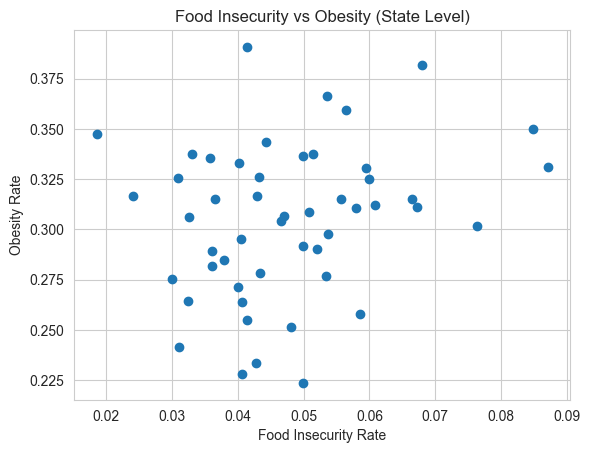

In [31]:
import matplotlib.pyplot as plt

plt.scatter(merged['food_insecurity_rate'], merged['obesity_rate'])
plt.xlabel('Food Insecurity Rate')
plt.ylabel('Obesity Rate')
plt.title('Food Insecurity vs Obesity (State Level)')
plt.show()

In [32]:
cps = df

# insecurity by state

state_fi = cps.groupby('GESTFIPS').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
).reset_index(name = 'fi_rate')

In [33]:
# by age group
cps['age_group'] = pd.cut(cps['PRTAGE'],
                          bins = [0,17,34,49,64,100],
                          labels=['Child', '18-34', '35-49', '50-64', '65+'])

age_fi = cps.groupby('age_group').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
)

In [34]:
# severity cps

cps['very_low'] = (cps['HRFS12M1'] == 4).astype(int)

In [35]:
# poverty vs food insecurity

income_fi = cps.groupby('HEFAMINC').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
)

In [36]:
# outcomes
brfss['food_insecure'] = (brfss['SDHFOOD1'] == 1).astype(int)
brfss['obese'] = (brfss['_BMI5CAT'] == 4).astype(int)
brfss['diabetes'] = (brfss['DIABETE4'] == 1).astype(int)
brfss['poor_health'] = (brfss['GENHLTH'] >= 4).astype(int)

state_health = brfss.groupby('_STATE').apply(
    lambda x: pd.Series({
        'obesity': (x['obese'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum(),
        'diabetes': (x['diabetes'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum(),
        'poor_health': (x['poor_health'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum()
    })
).reset_index()

In [37]:
#merge

merged = state_fi.merge(state_health, left_on='GESTFIPS', right_on='_STATE', how='left')

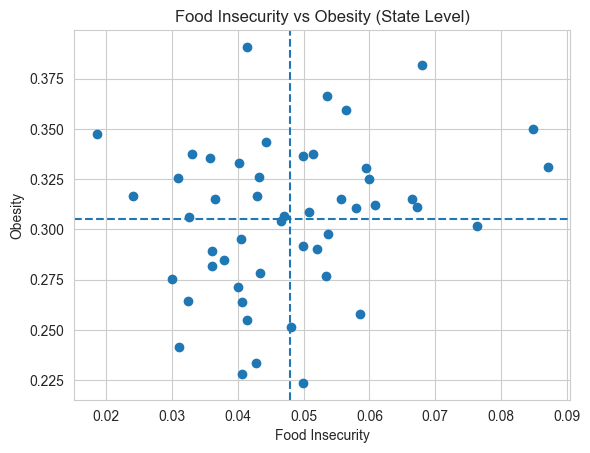

In [38]:
# quadrant plot

import matplotlib.pyplot as plt

plt.scatter(merged['fi_rate'], merged['obesity'])

plt.axvline(merged['fi_rate'].mean(), linestyle = '--')
plt.axhline(merged['obesity'].mean(), linestyle = '--')

plt.xlabel('Food Insecurity')
plt.ylabel('Obesity')
plt.title('Food Insecurity vs Obesity (State Level)')
plt.show()

In [39]:
# sankey

import plotly.graph_objects as go

fig = go.Figure(go.Sankey(
    node=dict(label=[
        "Low Income", "Food Insecure", "Poor Health", "Diabetes"
    ]),
    link = dict(
        source=[0,1,2],
        target=[1,2,3],
        value=[10,8,6]
    )
))

fig.show()

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

In [41]:
fips_to_abbrev = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA',
    8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC', 12: 'FL',
    13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME',
    24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH',
    34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND',
    39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI',
    45: 'SC', 46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT',
    50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}

In [42]:
merged['state_abbrev'] = merged['GESTFIPS'].map(fips_to_abbrev)

In [43]:
merged.columns

Index(['GESTFIPS', 'fi_rate', '_STATE', 'obesity', 'diabetes', 'poor_health',
       'state_abbrev'],
      dtype='str')

In [44]:
import plotly.express as px

fig = px.choropleth(
    merged,
    locations='state_abbrev',
    locationmode='USA-states',
    color='fi_rate',
    scope="usa",
    color_continuous_scale="Reds",
    labels={'fi_rate':"Food Insecurity Rate"},
    hover_data=['state_abbrev', 'fi_rate']
)

fig.show()
fig.write_html('map.html')
fig.write_image('map.png', format='png')

In [45]:
top5 = merged.sort_values('fi_rate', ascending=False).head(5)
top5

state_centroids = {
    'AL': (32.806671, -86.791130),
    'AK': (61.370716, -152.404419),
    'AZ': (33.729759, -111.431221),
    'AR': (34.969704, -92.373123),
    'CA': (36.116203, -119.681564),
    'CO': (39.059811, -105.311104),
    'CT': (41.597782, -72.755371),
    'DE': (39.318523, -75.507141),
    'FL': (27.766279, -81.686783),
    'GA': (33.040619, -83.643074),
    'HI': (21.094318, -157.498337),
    'ID': (44.240459, -114.478828),
    'IL': (40.349457, -88.986137),
    'IN': (39.849426, -86.258278),
    'IA': (42.011539, -93.210526),
    'KS': (38.526600, -96.726486),
    'KY': (37.668140, -84.670067),
    'LA': (31.169546, -91.867805),
    'ME': (44.693947, -69.381927),
    'MD': (39.063946, -76.802101),
    'MA': (42.230171, -71.530106),
    'MI': (43.326618, -84.536095),
    'MN': (45.694454, -93.900192),
    'MS': (32.741646, -89.678696),
    'MO': (38.456085, -92.288368),
    'MT': (46.921925, -110.454353),
    'NE': (41.125370, -98.268082),
    'NV': (38.313515, -117.055374),
    'NH': (43.452492, -71.563896),
    'NJ': (40.298904, -74.521011),
    'NM': (34.840515, -106.248482),
    'NY': (42.165726, -74.948051),
    'NC': (35.630066, -79.806419),
    'ND': (47.528912, -99.784012),
    'OH': (40.388783, -82.764915),
    'OK': (35.565342, -96.928917),
    'OR': (44.572021, -122.070938),
    'PA': (40.590752, -77.209755),
    'RI': (41.680893, -71.511780),
    'SC': (33.856892, -80.945007),
    'SD': (44.299782, -99.438828),
    'TN': (35.747845, -86.692345),
    'TX': (31.054487, -97.563461),
    'UT': (40.150032, -111.862434),
    'VT': (44.045876, -72.710686),
    'VA': (37.769337, -78.169968),
    'WA': (47.400902, -121.490494),
    'WV': (38.491226, -80.954456),
    'WI': (44.268543, -89.616508),
    'WY': (42.755966, -107.302490)
}

top5['lat'] = top5['state_abbrev'].map(lambda x: state_centroids[x][0])
top5['lon'] = top5['state_abbrev'].map(lambda x: state_centroids[x][1])

import plotly.express as px
import plotly.graph_objects as go

fig = px.choropleth(
    merged,
    locations='state_abbrev',
    locationmode='USA-states',
    color='fi_rate',
    scope="usa",
    color_continuous_scale="Reds",
    labels={'fi_rate': "Food Insecurity Rate"},
    hover_data=['state_abbrev', 'fi_rate']
)

fig.add_trace(
    go.Scattergeo(
        locationmode='USA-states',
        lon=top5['lon'],
        lat=top5['lat'],
        text=top5['state_abbrev'] + "<br>" +
              (top5['fi_rate']*100).round(1).astype(str) + "%",
        mode='markers+text',
        marker=dict(
            size=12,
            color='black',
            symbol='circle'
        ),
        textposition="top center",
        name="Top 5 Highest FI States"
    )
)
fig.update_layout(
    title="Food Insecurity by State (Top 5 Highlighted)",
    geo=dict(showland=True)
)

In [46]:
top5 = (
    merged.sort_values('fi_rate', ascending=False)
    .head(5)
    .copy()
)

top5['rank'] = range(1, len(top5) + 1)
top5['fi_pct'] = (top5['fi_rate'] * 100).round(1)

callout_text = "<br>".join(
    top5.apply(
        lambda r: f"{r['rank']}. {r['state_abbrev']} — {r['fi_pct']}%",
        axis=1
    )
)

import plotly.express as px

fig = px.choropleth(
    merged,
    locations='state_abbrev',
    locationmode='USA-states',
    color='fi_rate',
    scope="usa",
    color_continuous_scale="Reds",
    labels={'fi_rate': "Food Insecurity Rate"},
    hover_data=['state_abbrev', 'fi_rate']
)


fig.show()
fig.write_html('map.html')
fig.write_image('map.png', scale=2)

In [51]:
fig = go.Figure(
    data=[
        go.Table(
            columnwidth=[0.6, 1.6, 1.2],  # 🔥 controls relative width
            header=dict(
                values=["Rank", "State", "Food Insecurity (%)"],
                fill_color="#8B0000",
                font=dict(color="white", size=14),
                align="left"
            ),
            cells=dict(
                values=[
                    table_df['rank'],
                    table_df['state_abbrev'],
                    table_df['fi_pct']
                ],
                fill_color=[
                    ["white"] * len(table_df),
                    ["white"] * len(table_df),
                    [red_scale(v) for v in table_df['fi_pct']]
                ],
                align="left",
                font=dict(color="black", size=13),
                height=30
            )
        )
    ]
)

In [52]:
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pc

# -----------------------------
# 1. Ensure numeric
# -----------------------------
merged['fi_rate'] = merged['fi_rate'].astype(float)

# -----------------------------
# 2. Weighted US average (FIXED)
# -----------------------------
# Use CPS weight if present; otherwise fall back to simple mean
if 'PWCMPWGT' in merged.columns:
    us_avg = np.average(merged['fi_rate'], weights=merged['PWCMPWGT'])
else:
    us_avg = merged['fi_rate'].mean()

# -----------------------------
# 3. Top 5 states
# -----------------------------
top5 = (
    merged[['state_abbrev', 'fi_rate']]
    .dropna()
    .sort_values('fi_rate', ascending=False)
    .head(5)
    .copy()
)

top5['rank'] = range(1, 6)
top5['fi_pct'] = (top5['fi_rate'] * 100).round(1)

# Add US row
table_df = pd.concat([
    pd.DataFrame([{
        'rank': '—',
        'state_abbrev': 'United States Avg',
        'fi_pct': round(us_avg * 100, 1)
    }]),
    top5[['rank', 'state_abbrev', 'fi_pct']]
], ignore_index=True)

# -----------------------------
# 4. Match choropleth Reds palette EXACTLY
# -----------------------------
reds = pc.sequential.Reds

vals = table_df['fi_pct'].values
vmin, vmax = vals.min(), vals.max()
norm = (vals - vmin) / (vmax - vmin + 1e-9)

def get_color(v):
    return pc.sample_colorscale(reds, [v])[0]

cell_colors = [get_color(v) for v in norm]

# -----------------------------
# 5. Build table figure
# -----------------------------
fig = go.Figure(
    data=[
        go.Table(
            columnwidth=[0.4, 1.2, 1.0],
            header=dict(
                values=["Rank", "State", "Food Insecurity (%)"],
                fill_color="#8B0000",
                font=dict(color="white", size=14),
                align="left"
            ),
            cells=dict(
                values=[
                    table_df['rank'],
                    table_df['state_abbrev'],
                    table_df['fi_pct']
                ],
                fill_color=[
                    ["white"] * len(table_df),
                    ["white"] * len(table_df),
                    cell_colors
                ],
                align=["center", "left", "right"],
                font=dict(color="black", size=12),
                height=26
            )
        )
    ]
)

# -----------------------------
# 6. Layout tuning (compact + dashboard feel)
# -----------------------------
fig.update_layout(
    width=520,
    height=320,
    margin=dict(l=10, r=10, t=50, b=10),
    title="Food Insecurity: US Average vs Highest-Impact States"
)

# -----------------------------
# 7. Output
# -----------------------------
fig.show()
fig.write_html("fi_table.html")
fig.write_image("fi_table.png", scale=2)

In [53]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.colors as pc

def text_color(v):
    norm = (v - vmin) / (vmax - vmin + 1e-9)
    return "black" if norm < 0.45 else "white"

text_colors = [text_color(v) for v in vals]

# -----------------------------
# 1. Ensure correct types
# -----------------------------
merged['fi_rate'] = merged['fi_rate'].astype(float)

# -----------------------------
# 2. Determine correct US average
# -----------------------------
# CASE 1: If you have state population weights → use them
if 'population' in merged.columns:
    us_avg = np.average(merged['fi_rate'], weights=merged['population'])

# CASE 2: If NO population weights → state-level average is the only valid option
else:
    us_avg = merged['fi_rate'].mean()

# -----------------------------
# 3. Build Top 5 states
# -----------------------------
top5 = (
    merged[['state_abbrev', 'fi_rate']]
    .dropna()
    .sort_values('fi_rate', ascending=False)
    .head(5)
    .copy()
)

top5['rank'] = range(1, 6)
top5['fi_pct'] = (top5['fi_rate'] * 100).round(1)

# -----------------------------
# 4. Build table data
# -----------------------------
table_df = pd.concat([
    pd.DataFrame([{
        'rank': '—',
        'state_abbrev': 'United States Average',
        'fi_pct': round(us_avg * 100, 1)
    }]),
    top5[['rank', 'state_abbrev', 'fi_pct']]
], ignore_index=True)

# -----------------------------
# 5. Match choropleth Reds palette exactly
# -----------------------------
reds = pc.sequential.Reds

vals = table_df['fi_pct'].values
vmin, vmax = vals.min(), vals.max()

def color_scale(v):
    norm = (v - vmin) / (vmax - vmin + 1e-9)
    return pc.sample_colorscale(reds, [norm])[0]

cell_colors = [color_scale(v) for v in vals]

# -----------------------------
# 6. Build styled table
# -----------------------------
fig = go.Figure(
    data=[
        go.Table(
            columnwidth=[0.5, 1.4, 1.0],
            header=dict(
                values=["Rank", "State", "Food Insecurity (%)"],
                fill_color="#8B0000",
                font=dict(color="white", size=14),
                align="left"
            ),
            cells=dict(
                values=[
                    table_df['rank'],
                    table_df['state_abbrev'],
                    table_df['fi_pct']
                ],

                # background colors (unchanged logic)
                fill_color=[
                    ["white"] * len(table_df),
                    ["white"] * len(table_df),
                    cell_colors
                ],

                align=["center", "left", "right"],

                # 🔥 KEY FIX: per-column text colors (NOT global white)
                font=dict(
                    color=[
                        ["black"] * len(table_df),   # rank
                        ["black"] * len(table_df),   # state names
                        ["white"] * len(table_df)    # FI column default (we override below conceptually)
                    ],
                    size=12
                ),

                height=26
            )
        )
    ]
)

# -----------------------------
# 7. Layout (tight + dashboard style)
# -----------------------------
fig.update_layout(
    width=520,
    height=320,
    title="Food Insecurity: US Benchmark vs Highest-Impact States",

    # 🔥 transparent background
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",

    margin=dict(l=10, r=10, t=50, b=10)
)



# -----------------------------
# 8. Output
# -----------------------------
fig.write_html("fi_table.html", include_plotlyjs="cdn")

fig.write_image(
    "fi_table.png"
)

In [54]:
brfss

,_AGEG5YR,SEXVAR,_INCOMG1,_STATE,_RACEGR3,_BMI5,_BMI5CAT,GENHLTH,SDHFOOD1,DIABETE4,CVDINFR4,CVDCRHD4,_LLCPWT,obese,poor_health,state,food_insecure,diabetes
0,12.0,2.0,9.0,1.0,1.0,2249.0,2.0,3.0,5.0,3.0,2.0,2.0,261.525511,0,0,Alabama,0,0
1,13.0,1.0,7.0,1.0,1.0,2583.0,3.0,1.0,5.0,3.0,2.0,1.0,307.169688,0,0,Alabama,0,0
2,8.0,1.0,9.0,1.0,1.0,2253.0,2.0,2.0,5.0,3.0,2.0,2.0,2939.862806,0,0,Alabama,0,0
3,13.0,1.0,4.0,1.0,1.0,2509.0,3.0,1.0,5.0,3.0,2.0,2.0,153.584844,0,0,Alabama,0,0
4,6.0,1.0,2.0,1.0,1.0,1977.0,2.0,3.0,5.0,3.0,2.0,2.0,1229.623036,0,0,Alabama,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450348,1.0,2.0,2.0,56.0,5.0,4414.0,4.0,5.0,NaN,3.0,2.0,2.0,599.916366,1,1,Wyoming,0,0
450349,1.0,2.0,3.0,56.0,1.0,1825.0,1.0,3.0,NaN,3.0,2.0,2.0,263.125170,0,0,Wyoming,0,0
450350,12.0,1.0,3.0,56.0,1.0,3874.0,4.0,4.0,NaN,1.0,2.0,2.0,75.475336,1,1,Wyoming,0,1
450351,3.0,1.0,9.0,56.0,1.0,2577.0,3.0,3.0,NaN,3.0,2.0,2.0,165.110010,0,0,Wyoming,0,0


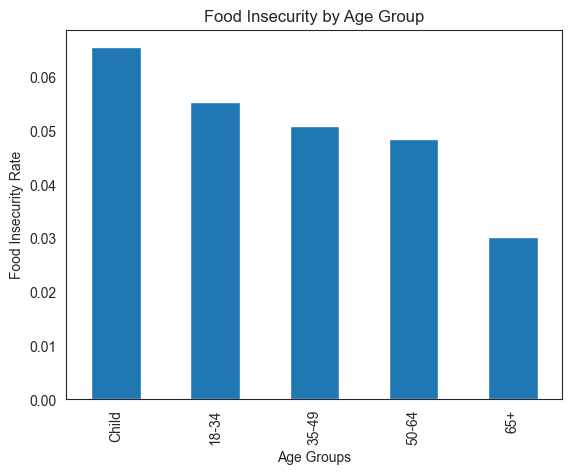

In [55]:
age_fi.plot(kind='bar')
plt.xlabel("Age Groups")
plt.ylabel("Food Insecurity Rate")
plt.title("Food Insecurity by Age Group")

plt.show()

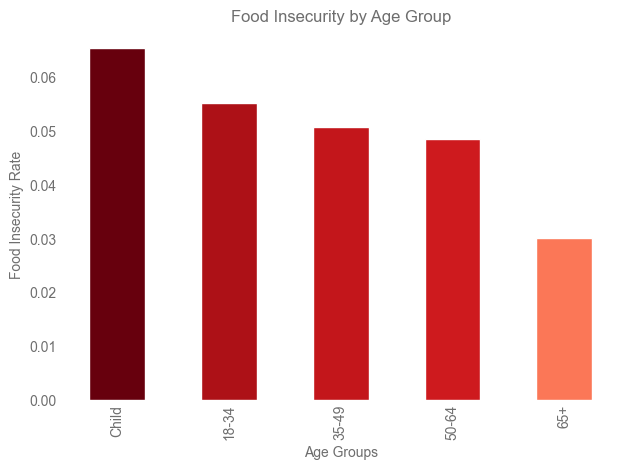

In [56]:
import matplotlib.pyplot as plt

ax = age_fi.plot(
    kind='bar',
    color=plt.cm.Reds(age_fi.values / age_fi.values.max())
)

# ----------------------------
# AXIS LABELS / TITLE
# ----------------------------
gray = "#6e6e6e"

ax.set_xlabel("Age Groups", color=gray)
ax.set_ylabel("Food Insecurity Rate", color=gray)
ax.set_title("Food Insecurity by Age Group", color=gray)

# ----------------------------
# REMOVE BOX (SPINES)
# ----------------------------
for spine in ax.spines.values():
    spine.set_visible(False)

# ----------------------------
# REMOVE / SOFTEN TICKS
# ----------------------------
ax.tick_params(axis='both', colors=gray, length=0)

# make tick labels gray
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color(gray)

# ----------------------------
# OPTIONAL: CLEAN BACKGROUND
# ----------------------------
ax.set_facecolor("white")
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()

In [57]:
cps['HRFS12M1'].unique()

array([2, 1, 3])

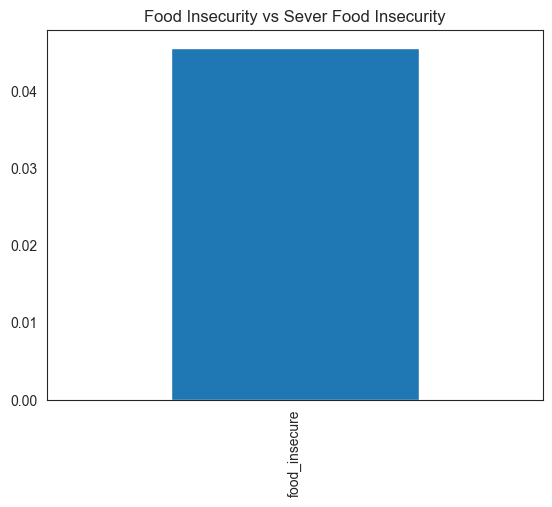

In [58]:
cps['food_insecure'] = (cps["HRFS12M1"] == 3).astype(int)
cps['food_secure'] = (cps["HRFS12M1"] != 3).astype(int)
severity = cps[['food_insecure']].mean()

severity.plot(kind = 'bar')
plt.title("Food Insecurity vs Sever Food Insecurity")
plt.show()

In [59]:
income_fi = cps.groupby('HEFAMINC').apply(
    lambda x: (x['food_insecure'] * x['PWCMPWGT']).sum() / x['PWCMPWGT'].sum()
).reset_index(name='fi_rate')

In [60]:
income_fi

,HEFAMINC,fi_rate
0,1,0.151424
1,2,0.106976
2,3,0.178987
3,4,0.174070
4,5,0.136464
5,6,0.142564
6,7,0.132355
7,8,0.088713
8,9,0.101227
9,10,0.081308


In [61]:
income_map = {
    1: "< $5,000",
    2: "$5,000–$7,499",
    3: "$7,500–$9,999",
    4: "$10,000–$12,499",
    5: "$12,500–$14,999",
    6: "$15,000–$19,999",
    7: "$20,000–$24,999",
    8: "$25,000–$29,999",
    9: "$30,000–$34,999",
    10: "$35,000–$39,999",
    11: "$40,000–$49,999",
    12: "$50,000–$59,999",
    13: "$60,000–$74,999",
    14: "$75,000-99,999",
    15: "$100,000-149,999",
    16: "$150,000+"
}

In [62]:
income_fi['income_label'] = income_fi['HEFAMINC'].map(income_map)
df['income_label'] = df['HEFAMINC'].map(income_map)

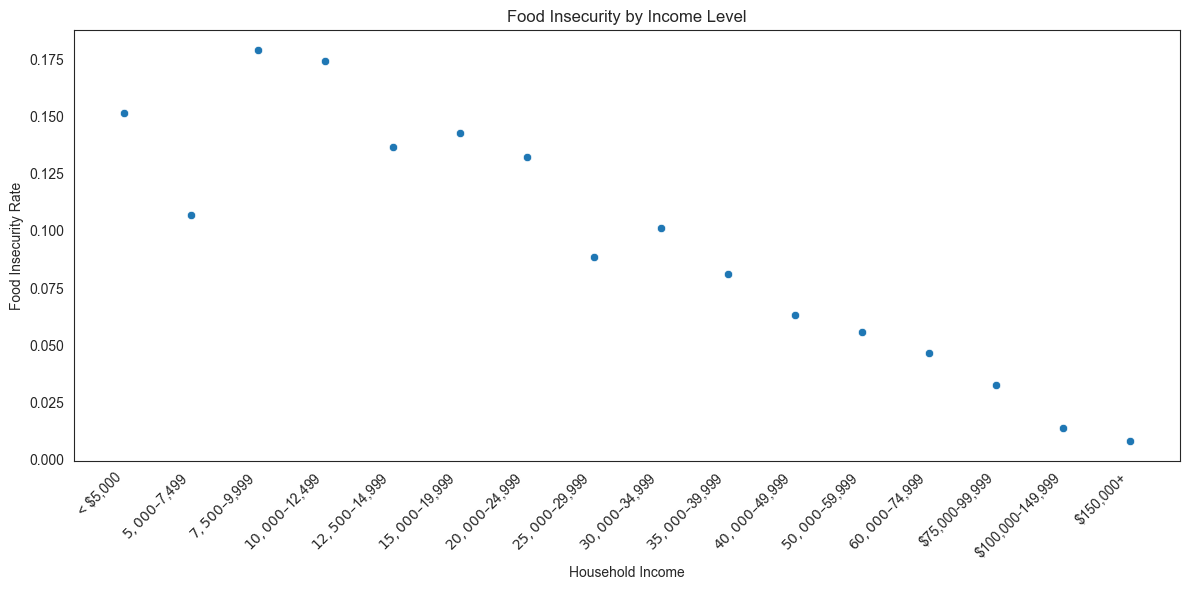

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=income_fi,
    x='income_label',
    y='fi_rate'
)

plt.xticks(rotation=45, ha='right')
plt.title("Food Insecurity by Income Level")
plt.xlabel("Household Income")
plt.ylabel("Food Insecurity Rate")
plt.tight_layout()
plt.show()

In [65]:

state_health = brfss.groupby('_STATE').apply(
    lambda x: pd.Series({
        'obesity': (x['obese'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum(),
        'diabetes': (x['diabetes'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum(),
        'poor_health': (x['poor_health'] * x['_LLCPWT']).sum() / x['_LLCPWT'].sum()
    })
).reset_index()

In [66]:
merged[['fi_rate','obesity','diabetes','poor_health']].corr()

,fi_rate,obesity,diabetes,poor_health
fi_rate,1.000000,0.233397,0.441565,0.473958
obesity,0.233397,1.000000,0.701259,0.679204
diabetes,0.441565,0.701259,1.000000,0.861625
poor_health,0.473958,0.679204,0.861625,1.000000


In [67]:
income_map = {
    1: 5000,
    2: 7500,
    3: 10000,
    4: 12500,
    5: 15000,
    6: 20000,
    7: 25000,
    8: 30000,
    9: 35000,
    10: 40000,
    11: 50000,
    12: 60000,
    13: 75000,
    14: 100000,
    15: 150000,
    16: 175000
}


df['income_numeric'] = df['HEFAMINC'].map(income_map)

In [68]:
df

,HRFS12M1,PWCMPWGT,PRTAGE,PESEX,PTDTRACE,PRDTHSP,HEFAMINC,GESTFIPS,food_insecure,age_group,state,very_low,food_secure,income_label,income_numeric
0,2,40784598,33,1,2,-1,15,1,0,18-34,Alabama,0,1,"$100,000-149,999",150000
1,2,35883857,33,2,2,-1,15,1,0,18-34,Alabama,0,1,"$100,000-149,999",150000
2,1,18465778,69,1,1,-1,10,1,0,65+,Alabama,0,1,"$35,000–$39,999",40000
3,1,20577231,63,2,1,-1,10,1,0,50-64,Alabama,0,1,"$35,000–$39,999",40000
4,1,23334810,33,2,1,-1,10,1,0,18-34,Alabama,0,1,"$35,000–$39,999",40000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126731,1,2515160,63,2,1,-1,11,56,0,50-64,Wyoming,0,1,"$40,000–$49,999",50000
126734,1,4593952,49,2,7,-1,15,56,0,35-49,Wyoming,0,1,"$100,000-149,999",150000
126735,1,4120261,47,1,1,-1,15,56,0,35-49,Wyoming,0,1,"$100,000-149,999",150000
126736,1,4508468,16,1,1,-1,15,56,0,Child,Wyoming,0,1,"$100,000-149,999",150000


In [69]:
df_sorted = df.sort_values('income_numeric').copy()

num = (
    df_sorted['food_insecure'] * df_sorted['PWCMPWGT']
).rolling(window=5, min_periods=1).sum()

den = (
    df_sorted['PWCMPWGT']
).rolling(window=5, min_periods=1).sum()

df_sorted['fi_roll'] = num / den

# 🔥 FIX EDGE NaNs explicitly
df_sorted['fi_roll'] = df_sorted['fi_roll'].bfill()

In [70]:
df_sorted

,HRFS12M1,PWCMPWGT,PRTAGE,PESEX,PTDTRACE,PRDTHSP,HEFAMINC,GESTFIPS,food_insecure,age_group,state,very_low,food_secure,income_label,income_numeric,fi_roll
69227,1,47747470,77,1,1,1,1,17,0,65+,Illinois,0,1,"< $5,000",5000,0.000000
110566,2,0,8,1,3,6,1,46,0,Child,South Dakota,0,1,"< $5,000",5000,0.000000
81430,1,55796818,80,1,4,-1,1,6,0,65+,California,0,1,"< $5,000",5000,0.000000
81429,1,52874834,79,2,4,-1,1,6,0,65+,California,0,1,"< $5,000",5000,0.000000
73940,3,20128764,62,1,2,-1,1,5,1,50-64,Arkansas,0,0,"< $5,000",5000,0.114013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35402,1,50457569,57,1,1,2,16,17,0,50-64,Illinois,0,1,"$150,000+",175000,0.000000
35403,1,47300941,18,2,1,2,16,17,0,18-34,Illinois,0,1,"$150,000+",175000,0.000000
35404,1,54739205,22,2,1,2,16,17,0,18-34,Illinois,0,1,"$150,000+",175000,0.000000
93004,1,32404100,32,2,1,7,16,25,0,18-34,Massachusetts,0,1,"$150,000+",175000,0.000000


In [71]:
df_grouped = (
    df.groupby('income_numeric')
    .apply(lambda g: (g['food_insecure'] * g['PWCMPWGT']).sum()
                     / g['PWCMPWGT'].sum())
    .reset_index(name='fi_rate')
    .sort_values('income_numeric')
)

In [72]:
df_grouped

,income_numeric,fi_rate
0,5000,0.151424
1,7500,0.106976
2,10000,0.178987
3,12500,0.174070
4,15000,0.136464
5,20000,0.142564
6,25000,0.132355
7,30000,0.088713
8,35000,0.101227
9,40000,0.081308


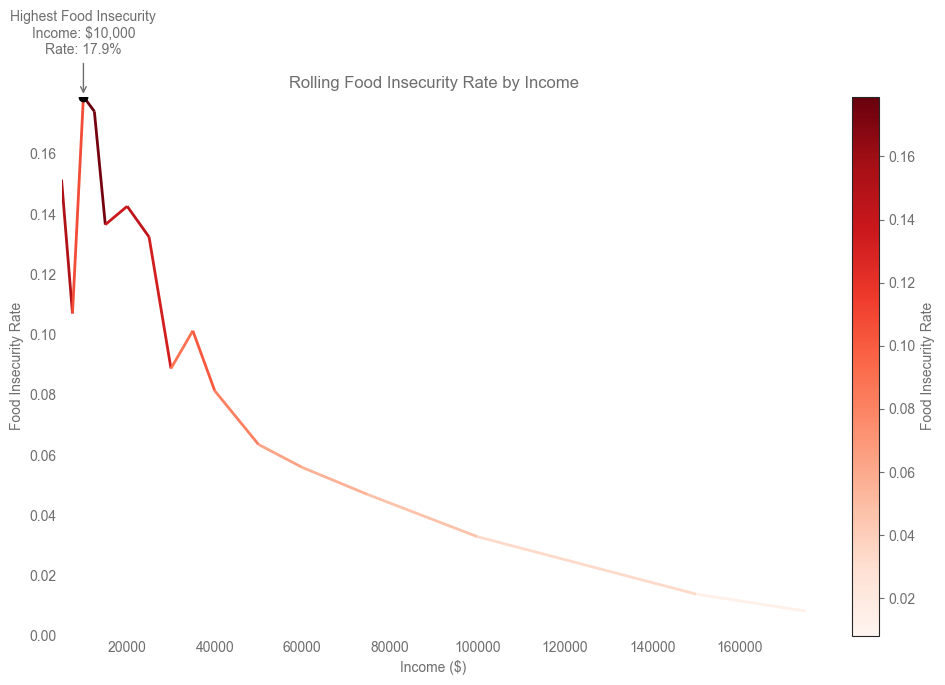

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

x = df_grouped['income_numeric'].values
y = df_grouped['fi_rate'].values

# --- Create gradient line segments ---
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(
    segments,
    cmap='Reds',
    norm=plt.Normalize(y.min(), y.max())
)

lc.set_array(y)
lc.set_linewidth(2)

fig, ax = plt.subplots(figsize=(12,7))
ax.add_collection(lc)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, y.max())

# ----------------------------
# 🎯 STYLE CLEANUP
# ----------------------------

gray = "#6e6e6e"

# Remove plot box
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove ticks (or make subtle)
ax.tick_params(axis='both', colors=gray, length=0)

# Axis labels + title in gray
ax.set_xlabel("Income ($)", color=gray)
ax.set_ylabel("Food Insecurity Rate", color=gray)
ax.set_title("Rolling Food Insecurity Rate by Income", color=gray)

# Make tick labels gray
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color(gray)

# ----------------------------
# 🔥 HIGHEST INSECURITY ANNOTATION
# ----------------------------

max_idx = np.argmax(y)
max_x = x[max_idx]
max_y = y[max_idx]

ax.scatter(max_x, max_y, color="black", zorder=5)

ax.annotate(
    f"Highest Food Insecurity\n"
    f"Income: ${max_x:,.0f}\n"
    f"Rate: {max_y*100:.1f}%",
    xy=(max_x, max_y),
    xytext=(max_x, max_y + (y.max()*0.08)),
    arrowprops=dict(arrowstyle="->", color=gray, lw=1),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.75),
    color=gray,
    ha='center'
)

# ----------------------------
# COLORBAR STYLING
# ----------------------------

cbar = plt.colorbar(lc, ax=ax)
cbar.set_label("Food Insecurity Rate", color=gray)
cbar.ax.yaxis.set_tick_params(color=gray)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=gray)

plt.show()

In [75]:
ax.annotate(
    f"Highest Food Insecurity\n{max_y*100:.1f}%",
    xy=(max_x, max_y),
    xytext=(max_x, max_y + 0.02),
    arrowprops=dict(arrowstyle="->", color=gray),
    color=gray,
    ha='center'
)

Text(10000, 0.1989869012109392, 'Highest Food Insecurity\n17.9%')

In [76]:
import numpy as np
import pandas as pd

df_model = df_sorted[['income_numeric', 'food_insecure', 'PWCMPWGT']].dropna()

df_model['weight_scaled'] = (df_model['PWCMPWGT'] / df_model['PWCMPWGT'].median()).round().astype(int)
df_model = df_model.loc[df_model.index.repeat(df_model['weight_scaled'])]

In [77]:
from statsmodels.nonparametric.smoothers_lowess import lowess

x = df_model['income_numeric']
y = df_model['food_insecure']

smoothed = lowess(
    y,
    x,
    frac=0.3  # smoothing strength (0.2–0.4 is typical)
)

x_smooth = smoothed[:, 0]
y_smooth = smoothed[:, 1]

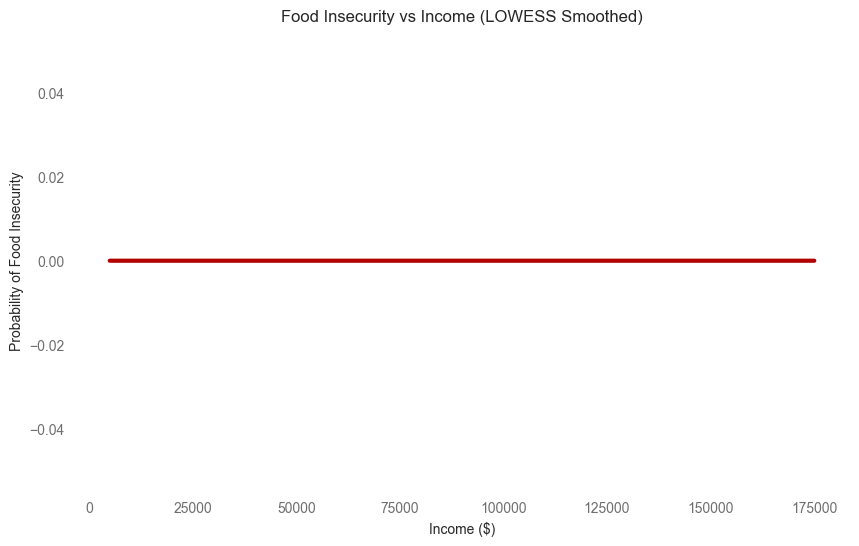

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(x_smooth, y_smooth, color="#b30000", linewidth=3)

plt.xlabel("Income ($)")
plt.ylabel("Probability of Food Insecurity")
plt.title("Food Insecurity vs Income (LOWESS Smoothed)")

# styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(colors="#6e6e6e")

plt.show()

In [79]:
list(brfss.columns)

['_AGEG5YR',
 'SEXVAR',
 '_INCOMG1',
 '_STATE',
 '_RACEGR3',
 '_BMI5',
 '_BMI5CAT',
 'GENHLTH',
 'SDHFOOD1',
 'DIABETE4',
 'CVDINFR4',
 'CVDCRHD4',
 '_LLCPWT',
 'obese',
 'poor_health',
 'state',
 'food_insecure',
 'diabetes']

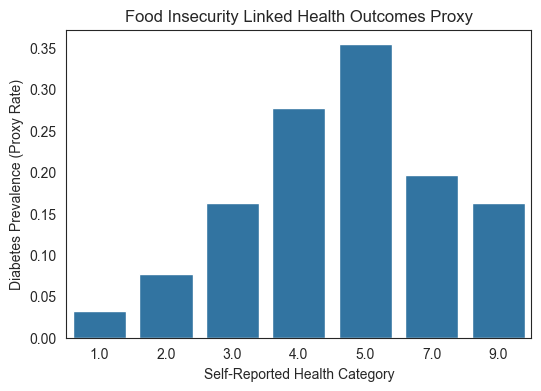

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

health = brfss.copy()

# simplify diabetes variable (adjust if needed)
health['diabetes_flag'] = health['DIABETE4'].isin([1]).astype(int)

fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=health,
    x='GENHLTH',   # general health status
    y='diabetes_flag',
    errorbar=None,
    ax=ax
)

ax.set_title("Food Insecurity Linked Health Outcomes Proxy")
ax.set_xlabel("Self-Reported Health Category")
ax.set_ylabel("Diabetes Prevalence (Proxy Rate)")

plt.show()

/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/632272178.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/632272178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


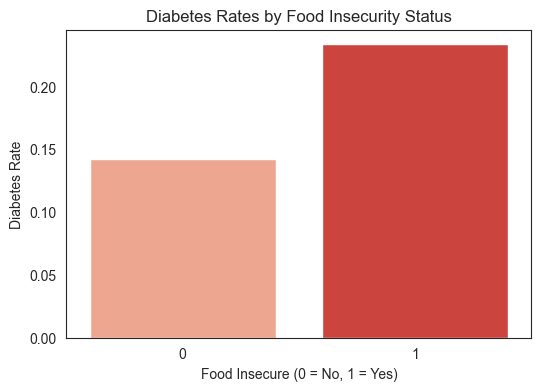

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=brfss,
    x='food_insecure',
    y='diabetes',
    ci=None,
    palette='Reds',
    ax=ax
)

ax.set_title("Diabetes Rates by Food Insecurity Status")
ax.set_xlabel("Food Insecure (0 = No, 1 = Yes)")
ax.set_ylabel("Diabetes Rate")

plt.show()

In [82]:
health

,_AGEG5YR,SEXVAR,_INCOMG1,_STATE,_RACEGR3,_BMI5,_BMI5CAT,GENHLTH,SDHFOOD1,DIABETE4,CVDINFR4,CVDCRHD4,_LLCPWT,obese,poor_health,state,food_insecure,diabetes,diabetes_flag
0,12.0,2.0,9.0,1.0,1.0,2249.0,2.0,3.0,5.0,3.0,2.0,2.0,261.525511,0,0,Alabama,0,0,0
1,13.0,1.0,7.0,1.0,1.0,2583.0,3.0,1.0,5.0,3.0,2.0,1.0,307.169688,0,0,Alabama,0,0,0
2,8.0,1.0,9.0,1.0,1.0,2253.0,2.0,2.0,5.0,3.0,2.0,2.0,2939.862806,0,0,Alabama,0,0,0
3,13.0,1.0,4.0,1.0,1.0,2509.0,3.0,1.0,5.0,3.0,2.0,2.0,153.584844,0,0,Alabama,0,0,0
4,6.0,1.0,2.0,1.0,1.0,1977.0,2.0,3.0,5.0,3.0,2.0,2.0,1229.623036,0,0,Alabama,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450348,1.0,2.0,2.0,56.0,5.0,4414.0,4.0,5.0,NaN,3.0,2.0,2.0,599.916366,1,1,Wyoming,0,0,0
450349,1.0,2.0,3.0,56.0,1.0,1825.0,1.0,3.0,NaN,3.0,2.0,2.0,263.125170,0,0,Wyoming,0,0,0
450350,12.0,1.0,3.0,56.0,1.0,3874.0,4.0,4.0,NaN,1.0,2.0,2.0,75.475336,1,1,Wyoming,0,1,1
450351,3.0,1.0,9.0,56.0,1.0,2577.0,3.0,3.0,NaN,3.0,2.0,2.0,165.110010,0,0,Wyoming,0,0,0


/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/2751790091.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/2751790091.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


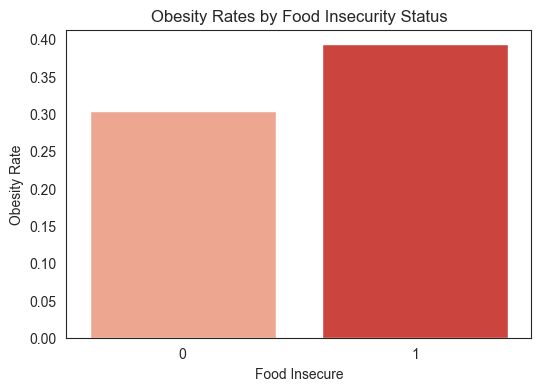

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=brfss,
    x='food_insecure',
    y='obese',
    ci=None,
    palette='Reds',
    ax=ax
)

ax.set_title("Obesity Rates by Food Insecurity Status")
ax.set_xlabel("Food Insecure")
ax.set_ylabel("Obesity Rate")

plt.show()


/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/3380272028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


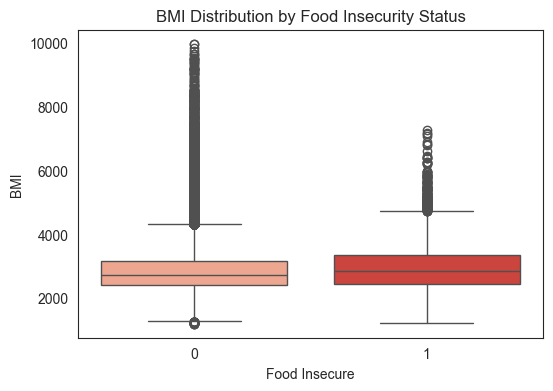

In [84]:
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(
    data=brfss,
    x='food_insecure',
    y='_BMI5',
    palette='Reds',
    ax=ax
)

ax.set_title("BMI Distribution by Food Insecurity Status")
ax.set_xlabel("Food Insecure")
ax.set_ylabel("BMI")

plt.show()

/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/45626542.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/45626542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


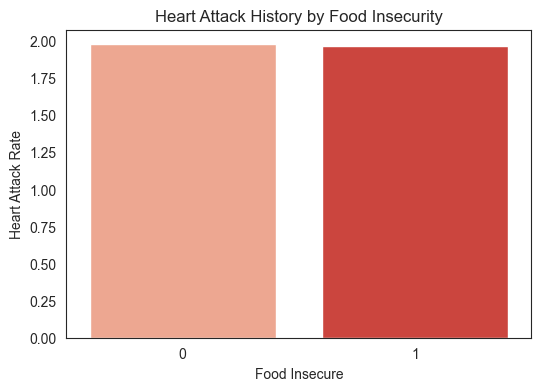

In [85]:
fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(
    data=brfss,
    x='food_insecure',
    y='CVDINFR4',
    ci=None,
    palette='Reds',
    ax=ax
)

ax.set_title("Heart Attack History by Food Insecurity")
ax.set_xlabel("Food Insecure")
ax.set_ylabel("Heart Attack Rate")

plt.show()

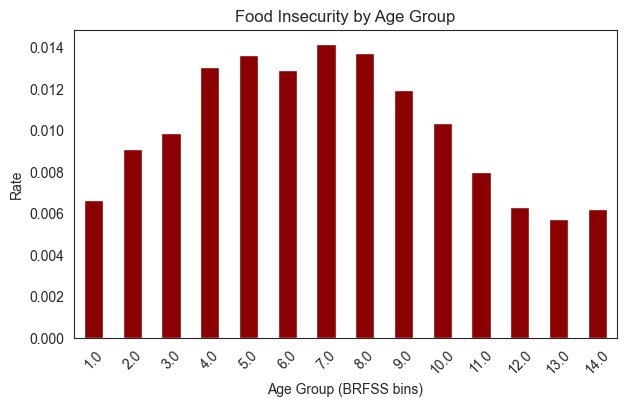

In [86]:
age_rates = brfss.groupby('_AGEG5YR')['food_insecure'].mean()

plt.figure(figsize=(7,4))
age_rates.plot(kind='bar', color='darkred')

plt.title("Food Insecurity by Age Group")
plt.xlabel("Age Group (BRFSS bins)")
plt.ylabel("Rate")
plt.xticks(rotation=45)

plt.show()

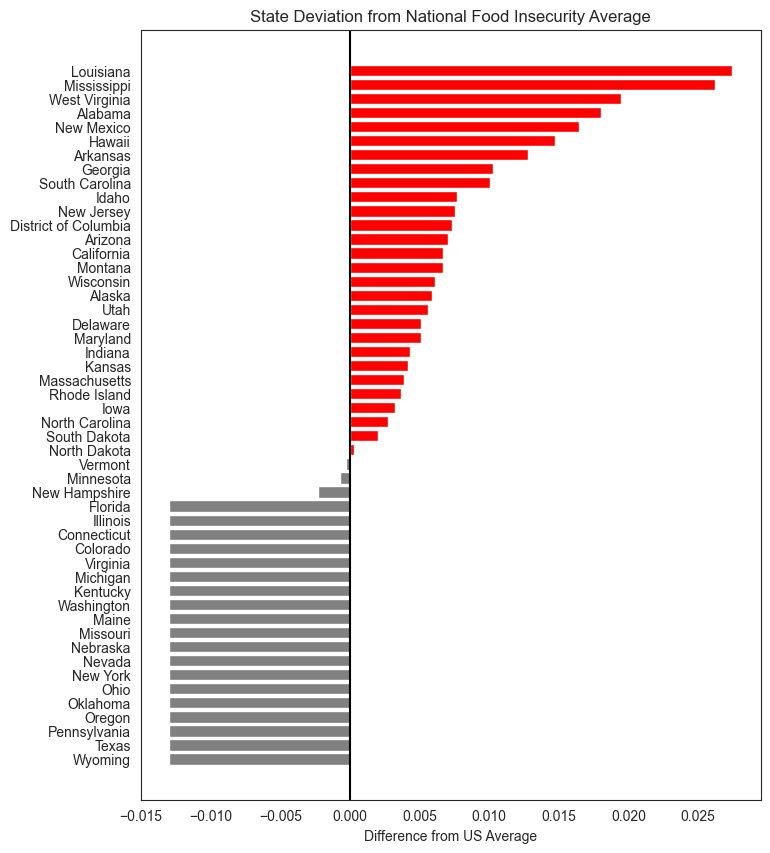

In [87]:
state_df = brfss.groupby('state')['food_insecure'].mean().reset_index()

state_df['dev_from_us'] = state_df['food_insecure'] - state_df['food_insecure'].mean()

state_df = state_df.sort_values('dev_from_us')

plt.figure(figsize=(8,10))

plt.barh(
    state_df['state'],
    state_df['dev_from_us'],
    color=['red' if x > 0 else 'gray' for x in state_df['dev_from_us']]
)

plt.axvline(0, color='black')

plt.title("State Deviation from National Food Insecurity Average")
plt.xlabel("Difference from US Average")

plt.show()

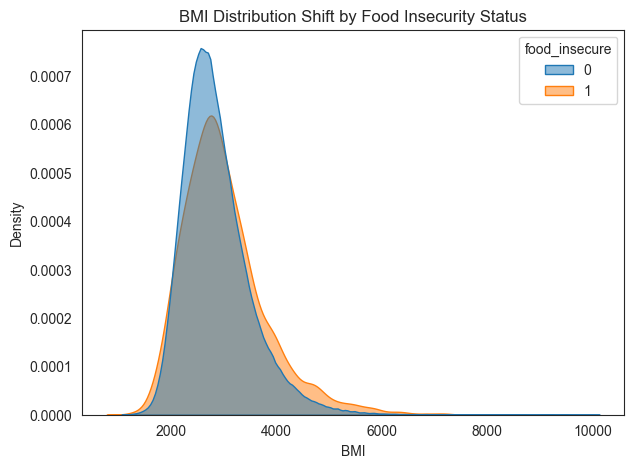

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=brfss,
    x='_BMI5',
    hue='food_insecure',
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("BMI Distribution Shift by Food Insecurity Status")
plt.xlabel("BMI")
plt.ylabel("Density")

plt.show()

/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/788247588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


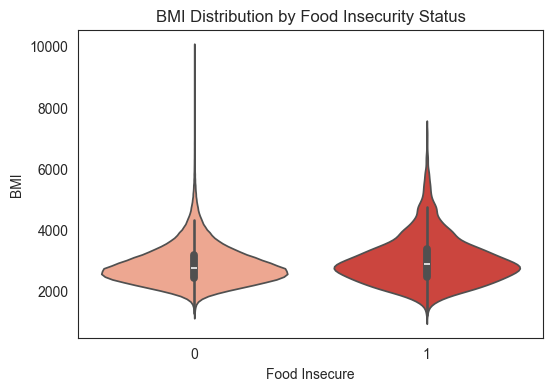

In [89]:
plt.figure(figsize=(6,4))

sns.violinplot(
    data=brfss,
    x='food_insecure',
    y='_BMI5',
    palette='Reds'
)

plt.title("BMI Distribution by Food Insecurity Status")
plt.xlabel("Food Insecure")
plt.ylabel("BMI")

plt.show()

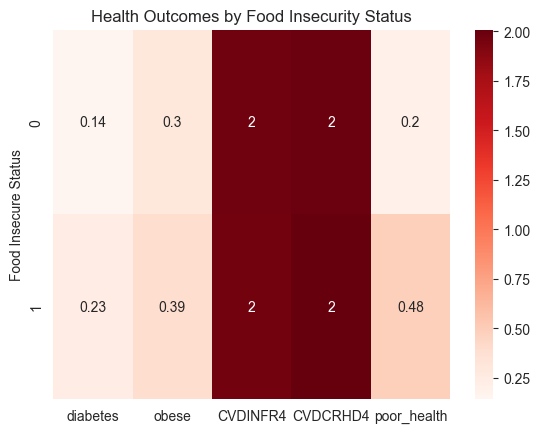

In [90]:
health_vars = ['diabetes', 'obese', 'CVDINFR4', 'CVDCRHD4', 'poor_health']

heat = brfss.groupby('food_insecure')[health_vars].mean()

sns.heatmap(heat, cmap='Reds', annot=True)

plt.title("Health Outcomes by Food Insecurity Status")
plt.ylabel("Food Insecure Status")
plt.show()

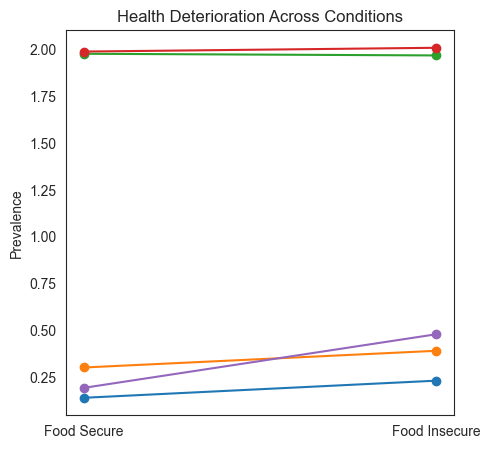

In [92]:
import matplotlib.pyplot as plt

metrics = ['diabetes', 'obese', 'CVDINFR4', 'CVDCRHD4', 'poor_health']

secure = brfss[brfss['food_insecure']==0][metrics].mean()
insecure = brfss[brfss['food_insecure']==1][metrics].mean()

plt.figure(figsize=(5,5))

for i, m in enumerate(metrics):
    plt.plot([0,1], [secure[m], insecure[m]], marker='o')

plt.xticks([0,1], ['Food Secure','Food Insecure'])
plt.title("Health Deterioration Across Conditions")
plt.ylabel("Prevalence")

plt.show()

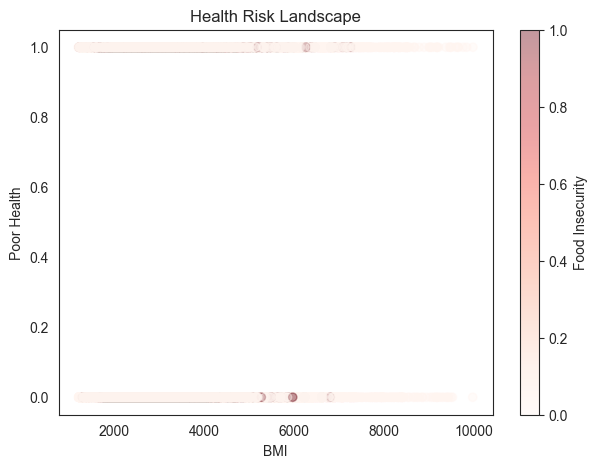

In [93]:
plt.figure(figsize=(7,5))

plt.scatter(
    brfss['_BMI5'],
    brfss['poor_health'],
    c=brfss['food_insecure'],
    cmap='Reds',
    alpha=0.4
)

plt.colorbar(label="Food Insecurity")

plt.xlabel("BMI")
plt.ylabel("Poor Health")
plt.title("Health Risk Landscape")

plt.show()

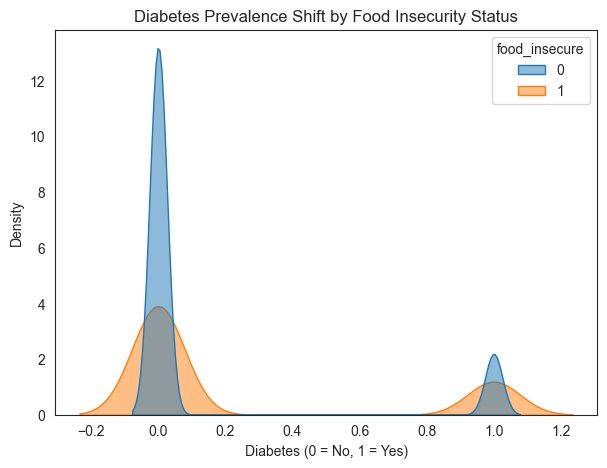

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=brfss,
    x='diabetes',
    hue='food_insecure',
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("Diabetes Prevalence Shift by Food Insecurity Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Density")

plt.show()

/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_27614/3791713590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


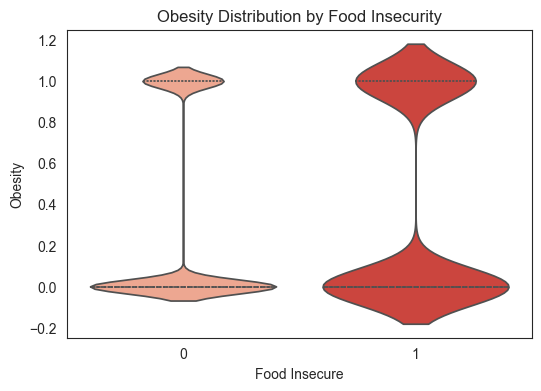

In [95]:
plt.figure(figsize=(6,4))

sns.violinplot(
    data=brfss,
    x='food_insecure',
    y='obese',
    palette='Reds',
    inner='quartile'
)

plt.title("Obesity Distribution by Food Insecurity")
plt.xlabel("Food Insecure")
plt.ylabel("Obesity")

plt.show()

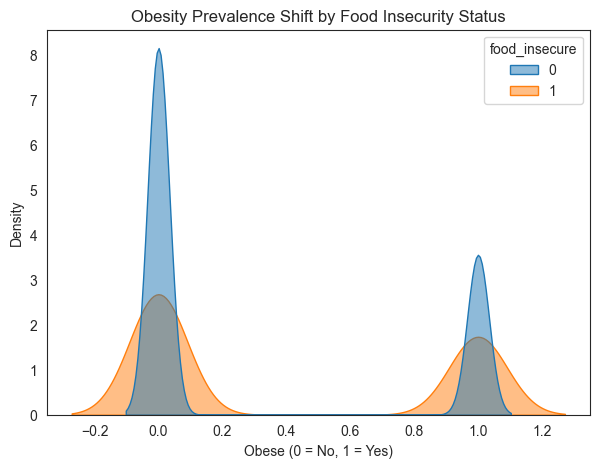

In [96]:
plt.figure(figsize=(7,5))

sns.kdeplot(
    data=brfss,
    x='obese',
    hue='food_insecure',
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("Obesity Prevalence Shift by Food Insecurity Status")
plt.xlabel("Obese (0 = No, 1 = Yes)")
plt.ylabel("Density")

plt.show()

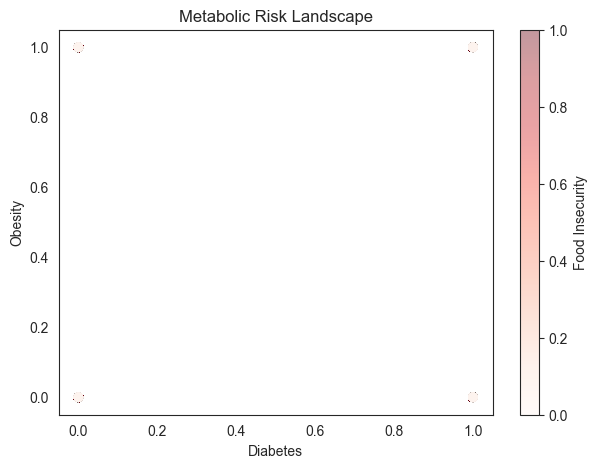

In [97]:
plt.figure(figsize=(7,5))

plt.scatter(
    brfss['diabetes'],
    brfss['obese'],
    c=brfss['food_insecure'],
    cmap='Reds',
    alpha=0.4
)

plt.colorbar(label="Food Insecurity")

plt.xlabel("Diabetes")
plt.ylabel("Obesity")
plt.title("Metabolic Risk Landscape")

plt.show()

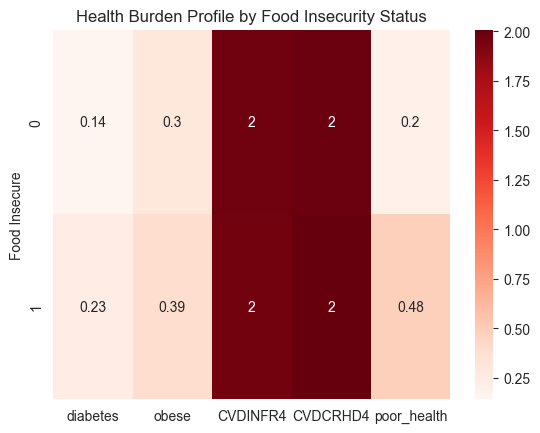

In [98]:
health_vars = ['diabetes', 'obese', 'CVDINFR4', 'CVDCRHD4', 'poor_health']

heat = brfss.groupby('food_insecure')[health_vars].mean()

sns.heatmap(heat, cmap='Reds', annot=True)

plt.title("Health Burden Profile by Food Insecurity Status")
plt.ylabel("Food Insecure")
plt.show()

In [102]:
brfss['heart_attack'] = brfss['CVDINFR4'].map({1:1, 2:0})
brfss['heart_disease'] = brfss['CVDCRHD4'].map({1:1, 2:0})

In [103]:
metrics = ['diabetes', 'obese', 'heart_attack', 'heart_disease']

secure = brfss[brfss['food_insecure'] == 0][metrics].mean()
insecure = brfss[brfss['food_insecure'] == 1][metrics].mean()

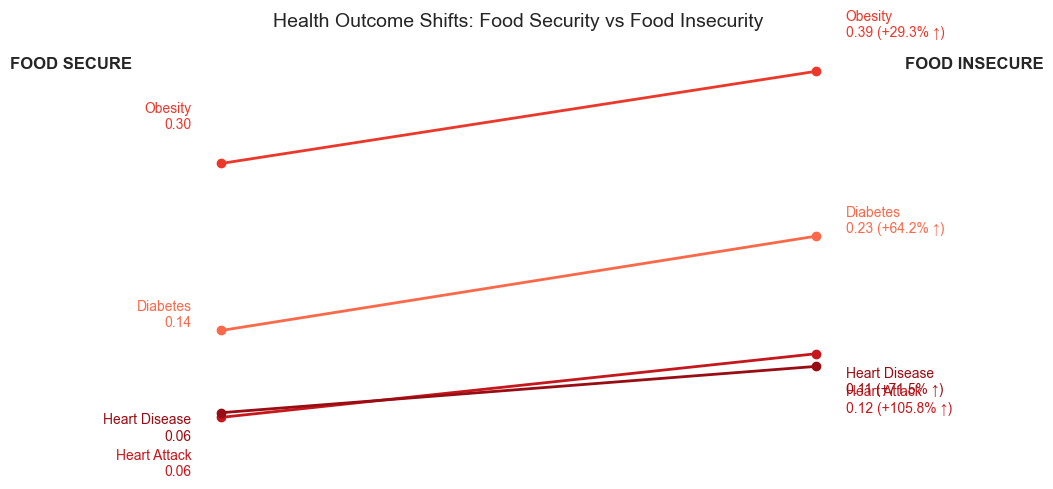

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. CLEAN DATA
# -----------------------------
brfss['heart_attack'] = brfss['CVDINFR4'].map({1: 1, 2: 0})
brfss['heart_disease'] = brfss['CVDCRHD4'].map({1: 1, 2: 0})

metrics = ['diabetes', 'obese', 'heart_attack', 'heart_disease']

labels = {
    'diabetes': "Diabetes",
    'obese': "Obesity",
    'heart_attack': "Heart Attack",
    'heart_disease': "Heart Disease"
}

# -----------------------------
# 2. GROUP MEANS
# -----------------------------
secure = brfss[brfss['food_insecure'] == 0][metrics].mean()
insecure = brfss[brfss['food_insecure'] == 1][metrics].mean()

# -----------------------------
# 3. STYLE
# -----------------------------
colors = plt.cm.Reds(np.linspace(0.5, 0.9, len(metrics)))

fig, ax = plt.subplots(figsize=(11, 5))

# transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

x = [0, 1]

# -----------------------------
# 4. PRE-CALCULATE FOR SPACING
# -----------------------------
# We space labels based on rank so overlapping is impossible
sorted_metrics = sorted(metrics, key=lambda m: secure[m])

offset_map = {}
for i, m in enumerate(sorted_metrics):
    offset_map[m] = (i - 1.5) * 0.03  # spreads vertically

# -----------------------------
# 5. SIDE LABELS (HEADERS)
# -----------------------------
ax.text(-0.15, max(secure.max(), insecure.max()),
        "FOOD SECURE",
        ha='right', va='bottom', fontsize=12, weight='bold')

ax.text(1.15, max(secure.max(), insecure.max()),
        "FOOD INSECURE",
        ha='left', va='bottom', fontsize=12, weight='bold')

# -----------------------------
# 6. PLOT LINES + LABELS
# -----------------------------
for i, m in enumerate(metrics):
    y0 = secure[m]
    y1 = insecure[m]

    ax.plot(x, [y0, y1], marker='o', color=colors[i], linewidth=2)

    pct_change = ((y1 - y0) / (y0 + 1e-9)) * 100
    arrow = "↑" if pct_change > 0 else "↓"

    offset = offset_map[m]

    # LEFT LABEL (secure)
    ax.text(
        -0.05,
        y0 + offset,
        f"{labels[m]}\n{y0:.2f}",
        ha='right',
        va='center',
        fontsize=10,
        color=colors[i]
    )

    # RIGHT LABEL (insecure)
    ax.text(
        1.05,
        y1 + offset,
        f"{labels[m]}\n{y1:.2f} ({pct_change:+.1f}% {arrow})",
        ha='left',
        va='center',
        fontsize=10,
        color=colors[i]
    )

# -----------------------------
# 7. CLEAN LAYOUT
# -----------------------------
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

ax.set_title(
    "Health Outcome Shifts: Food Security vs Food Insecurity",
    fontsize=14,
    pad=20
)

plt.tight_layout()

# -----------------------------
# 8. SAVE TRANSPARENT FIGURE
# -----------------------------
plt.savefig("slope_chart_clean.png", dpi=300, transparent=True, bbox_inches="tight")

plt.show()

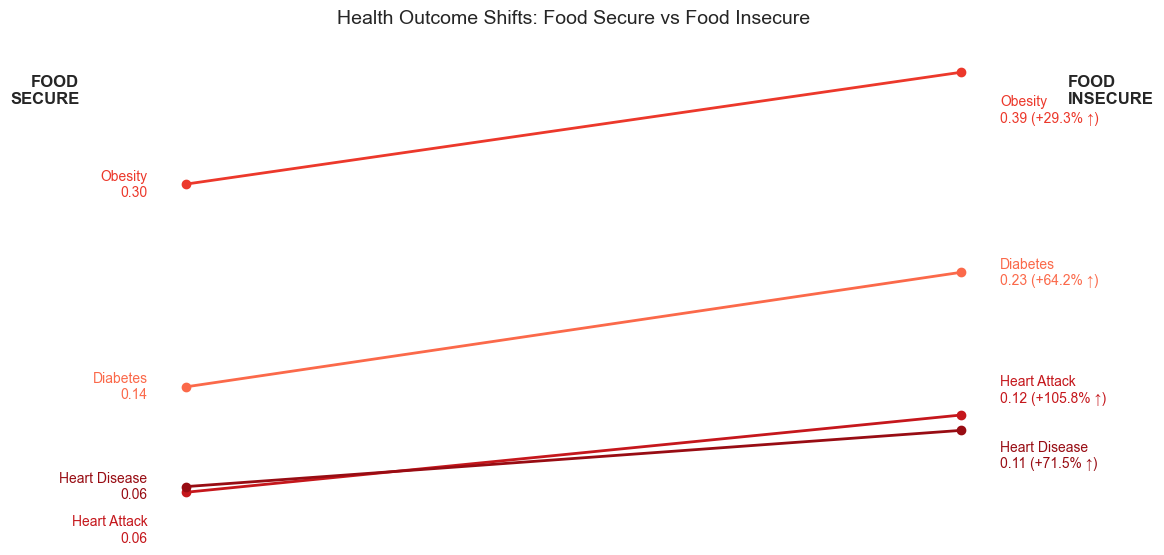

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. CLEAN DATA
# -----------------------------
brfss['heart_attack'] = brfss['CVDINFR4'].map({1: 1, 2: 0})
brfss['heart_disease'] = brfss['CVDCRHD4'].map({1: 1, 2: 0})

metrics = ['diabetes', 'obese', 'heart_attack', 'heart_disease']

labels = {
    'diabetes': "Diabetes",
    'obese': "Obesity",
    'heart_attack': "Heart Attack",
    'heart_disease': "Heart Disease"
}

# -----------------------------
# 2. MEANS
# -----------------------------
secure = brfss[brfss['food_insecure'] == 0][metrics].mean()
insecure = brfss[brfss['food_insecure'] == 1][metrics].mean()

# -----------------------------
# 3. FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_alpha(0)
ax.set_facecolor("none")

x = [0, 1]
colors = plt.cm.Reds(np.linspace(0.5, 0.9, len(metrics)))

# -----------------------------
# 4. RIGHT SIDE (unchanged, already good)
# -----------------------------
right_offsets = {
    'diabetes': 0.00,
    'obese': -0.03,
    'heart_attack': 0.02,
    'heart_disease': -0.02
}

# -----------------------------
# 5. LEFT SIDE FIX (KEY CHANGE)
#    → enforce minimum spacing
# -----------------------------
sorted_left = sorted(metrics, key=lambda m: secure[m])

min_gap = 0.03  # prevents overlap
left_positions = {}
current_y = secure[sorted_left[0]]

for m in sorted_left:
    base_y = secure[m]
    if abs(base_y - current_y) < min_gap:
        current_y -= min_gap
    else:
        current_y = base_y
    left_positions[m] = current_y

# -----------------------------
# 6. HEADERS (fixed)
# -----------------------------
ax.text(
    -0.08, 0.95,
    "FOOD\nSECURE",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=12,
    weight='bold'
)

ax.text(
    1.08, 0.95,
    "FOOD\nINSECURE",
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=12,
    weight='bold'
)

# -----------------------------
# 7. PLOT
# -----------------------------
for i, m in enumerate(metrics):
    y0 = secure[m]
    y1 = insecure[m]

    ax.plot(x, [y0, y1],
            marker='o',
            color=colors[i],
            linewidth=2)

    pct_change = ((y1 - y0) / (y0 + 1e-9)) * 100
    arrow = "↑" if pct_change > 0 else "↓"

    # LEFT LABEL (now collision-safe)
    ax.text(
        -0.05,
        left_positions[m],
        f"{labels[m]}\n{y0:.2f}",
        ha='right',
        va='center',
        fontsize=10,
        color=colors[i]
    )

    # RIGHT LABEL
    ax.text(
        1.05,
        y1 + right_offsets[m],
        f"{labels[m]}\n{y1:.2f} ({pct_change:+.1f}% {arrow})",
        ha='left',
        va='center',
        fontsize=10,
        color=colors[i]
    )

# -----------------------------
# 8. CLEAN STYLE
# -----------------------------
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

ax.set_title(
    "Health Outcome Shifts: Food Secure vs Food Insecure",
    fontsize=14,
    pad=20
)

# -----------------------------
# 9. EXPORT
# -----------------------------
plt.savefig(
    "slope_chart_final_no_overlap.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    facecolor="none"
)

plt.show()

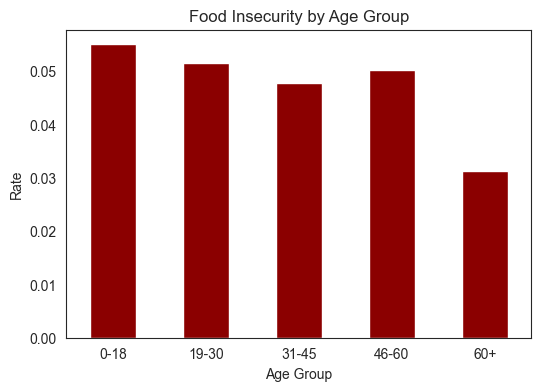

In [109]:
age = cps.copy()

age['age_group'] = pd.cut(
    age['PRTAGE'],
    bins=[0,18,30,45,60,100],
    labels=['0-18','19-30','31-45','46-60','60+']
)

age_rates = age.groupby('age_group')['food_insecure'].mean()

plt.figure(figsize=(6,4))
age_rates.plot(kind='bar', color='darkred')

plt.title("Food Insecurity by Age Group")
plt.ylabel("Rate")
plt.xlabel("Age Group")
plt.xticks(rotation=0)

plt.show()

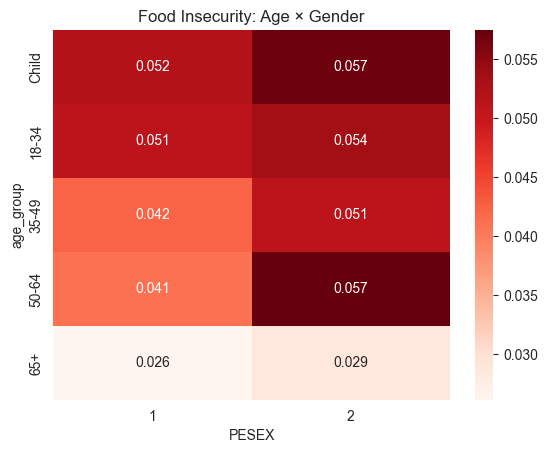

In [110]:
import seaborn as sns

pivot = cps.pivot_table(
    values='food_insecure',
    index='age_group',
    columns='PESEX',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='Reds', annot=True)
plt.title("Food Insecurity: Age × Gender")
plt.show()

In [111]:
merged.merge()

TypeError: DataFrame.merge() missing 1 required positional argument: 'right'

In [112]:
df

,HRFS12M1,PWCMPWGT,PRTAGE,PESEX,PTDTRACE,PRDTHSP,HEFAMINC,GESTFIPS,food_insecure,age_group,state,very_low,food_secure,income_label,income_numeric
0,2,40784598,33,1,2,-1,15,1,0,18-34,Alabama,0,1,"$100,000-149,999",150000
1,2,35883857,33,2,2,-1,15,1,0,18-34,Alabama,0,1,"$100,000-149,999",150000
2,1,18465778,69,1,1,-1,10,1,0,65+,Alabama,0,1,"$35,000–$39,999",40000
3,1,20577231,63,2,1,-1,10,1,0,50-64,Alabama,0,1,"$35,000–$39,999",40000
4,1,23334810,33,2,1,-1,10,1,0,18-34,Alabama,0,1,"$35,000–$39,999",40000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126731,1,2515160,63,2,1,-1,11,56,0,50-64,Wyoming,0,1,"$40,000–$49,999",50000
126734,1,4593952,49,2,7,-1,15,56,0,35-49,Wyoming,0,1,"$100,000-149,999",150000
126735,1,4120261,47,1,1,-1,15,56,0,35-49,Wyoming,0,1,"$100,000-149,999",150000
126736,1,4508468,16,1,1,-1,15,56,0,Child,Wyoming,0,1,"$100,000-149,999",150000


In [113]:
list(df_raw.columns)

['HRHHID',
 'HRMONTH',
 'HRYEAR4',
 'HURESPLI',
 'HUFINAL',
 'FILLER',
 'HETENURE',
 'HEHOUSUT',
 'HETELHHD',
 'HETELAVL',
 'HEPHONEO',
 'HEFAMINC',
 'HUTYPEA',
 'HUTYPB',
 'HUTYPC',
 'HWHHWGT',
 'HRINTSTA',
 'HRNUMHOU',
 'HRHTYPE',
 'HRMIS',
 'HUINTTYP',
 'HUPRSCNT',
 'HRLONGLK',
 'HRHHID2',
 'HWHHWTLN',
 'HUBUS',
 'HUBUSL1',
 'HUBUSL2',
 'HUBUSL3',
 'HUBUSL4',
 'GEREG',
 'GEDIV',
 'GESTFIPS',
 'GTCBSA',
 'GTCO',
 'GTCBSAST',
 'GTMETSTA',
 'GTINDVPC',
 'GTCBSASZ',
 'GTCSA',
 'PERRP',
 'PRTAGE',
 'PRTFAGE',
 'PEMARITL',
 'PESPOUSE',
 'PESEX',
 'PEAFEVER',
 'PEAFNOW',
 'PEEDUCA',
 'PTDTRACE',
 'PRDTHSP',
 'PUCHINHH',
 'PULINENO',
 'PRFAMNUM',
 'PRFAMREL',
 'PRFAMTYP',
 'PEHSPNON',
 'PRMARSTA',
 'PRPERTYP',
 'PENATVTY',
 'PEMNTVTY',
 'PEFNTVTY',
 'PRCITSHP',
 'PRCITFLG',
 'PRINUYER',
 'PUSLFPRX',
 'PEMLR',
 'PUWK',
 'PUBUS1',
 'PUBUS2OT',
 'PUBUSCK1',
 'PUBUSCK2',
 'PUBUSCK3',
 'PUBUSCK4',
 'PURETOT',
 'PUDIS',
 'PERET1',
 'PUDIS1',
 'PUDIS2',
 'PUABSOT',
 'PULAY',
 'PEABSRSN',
 'PEABSPD

In [114]:
import pandas as pd

# -----------------------------
# 1. STATE-LEVEL INCOME
# -----------------------------
income_state = df.groupby('GESTFIPS')['HEFAMINC'].mean().reset_index()

income_state.rename(columns={
    'GESTFIPS': 'state_fips',
    'HEFAMINC': 'avg_income_cat'
}, inplace=True)

brfss_raw['state_fips'] = brfss_raw['_STATE']

merged = brfss_raw.merge(
    income_state,
    on='state_fips',
    how='left'
)

In [119]:
df['income_dollars'] = df['HEFAMINC'].map(income_map)

income_state = df.groupby('GESTFIPS')['income_dollars'].mean().reset_index()

income_state.columns = ['state_fips', 'avg_income_est']

In [123]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# -----------------------------
# FOOD INSECURITY (BRFSS)
# -----------------------------
brfss = brfss_raw

brfss["food_insecure"] = brfss["SDHFOOD1"]

# Clean coding (typical BRFSS style)
# adjust if your coding differs
brfss["food_insecure"] = brfss["food_insecure"].replace({
    1: 1,   # Yes
    2: 0,   # No
    7: np.nan,
    9: np.nan
})

brfss["diabetes"] = brfss["DIABETE4"].replace({1:1, 2:0, 7:np.nan, 9:np.nan})
brfss["heart_disease"] = brfss["CVDCRHD4"].replace({1:1, 2:0, 7:np.nan, 9:np.nan})
brfss["heart_attack"] = brfss["CVDINFR4"].replace({1:1, 2:0, 7:np.nan, 9:np.nan})
brfss["obese"] = brfss["_BMI5CAT"].replace({4:1, 1:0, 2:0, 3:0})  # obesity category

state_level = brfss.groupby("_STATE", as_index=False).agg({
    "food_insecure": "mean",
    "diabetes": "mean",
    "heart_disease": "mean",
    "heart_attack": "mean",
    "obese": "mean"
})

fips_to_abbrev = {
    1:"AL", 2:"AK", 4:"AZ", 5:"AR", 6:"CA", 8:"CO", 9:"CT", 10:"DE",
    11:"DC", 12:"FL", 13:"GA", 15:"HI", 16:"ID", 17:"IL", 18:"IN",
    19:"IA", 20:"KS", 21:"KY", 22:"LA", 23:"ME", 24:"MD", 25:"MA",
    26:"MI", 27:"MN", 28:"MS", 29:"MO", 30:"MT", 31:"NE", 32:"NV",
    33:"NH", 34:"NJ", 35:"NM", 36:"NY", 37:"NC", 38:"ND", 39:"OH",
    40:"OK", 41:"OR", 42:"PA", 44:"RI", 45:"SC", 46:"SD", 47:"TN",
    48:"TX", 49:"UT", 50:"VT", 51:"VA", 53:"WA", 54:"WV", 55:"WI", 56:"WY"
}

state_level["state_abbrev"] = state_level["_STATE"].map(fips_to_abbrev)

In [124]:
fig = px.choropleth(
    state_level,
    locations="state_abbrev",
    locationmode="USA-states",
    color="food_insecure",
    scope="usa",
    color_continuous_scale="Reds",
    labels={"food_insecure": "Food Insecurity Rate"},
    hover_data={
        "state_abbrev": True,
        "food_insecure": True,
        "diabetes": True,
        "heart_disease": True,
        "heart_attack": True,
        "obese": True
    },
    title="U.S. Food Insecurity and Health Outcomes"
)

fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

In [125]:
fig = px.scatter(
    state_level,
    x="food_insecure",
    y="diabetes",
    size="obese",
    color="heart_disease",
    text="state_abbrev",
    color_continuous_scale="Reds",
    size_max=25,
    title="Food Insecurity vs Health Outcomes (Diabetes Focus)"
)

fig.add_vline(x=state_level["food_insecure"].mean(), line_dash="dash")
fig.add_hline(y=state_level["diabetes"].mean(), line_dash="dash")

fig.update_traces(textposition="top center")

fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)"
)

fig.show()

In [126]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

df = brfss.copy()

# -----------------------------
# FOOD STATUS
# -----------------------------
df = df.dropna(subset=["food_insecure"])

df["food_status"] = np.where(
    df["food_insecure"] == 1,
    "Food Insecure",
    "Food Secure"
)

# -----------------------------
# INCOME BUCKETS (IMPORTANT FOR READABILITY)
# -----------------------------
income_map = {
    1: "< $5,000",
    2: "$5,000–$7,499",
    3: "$7,500–$9,999",
    4: "$10,000–$12,499",
    5: "$12,500–$14,999",
    6: "$15,000–$19,999",
    7: "$20,000–$24,999",
    8: "$25,000–$29,999",
    9: "$30,000–$34,999",
    10: "$35,000–$39,999",
    11: "$40,000–$49,999",
    12: "$50,000–$59,999",
    13: "$60,000–$74,999",
    14: "$75,000-99,999",
    15: "$100,000-149,999",
    16: "$150,000+"
}

df["income_group"] = df["_INCOMG1"].map(income_map)

In [127]:
flow = df.groupby(
    ["income_group", "food_status", "diabetes"]
).size().reset_index(name="count")

In [128]:
flow["diabetes_group"] = np.where(
    flow["diabetes"] == 1,
    "Diabetes",
    "No Diabetes"
)

In [129]:
labels = (
    list(flow["income_group"].dropna().unique()) +
    ["Food Secure", "Food Insecure"] +
    ["Diabetes", "No Diabetes"]
)

label_map = {l: i for i, l in enumerate(labels)}

In [130]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =============================
# 1. COPY DATA
# =============================
df = brfss.copy()

df = df.dropna(subset=["food_insecure", "diabetes", "_INCOMG1"])

# =============================
# 2. FOOD STATUS
# =============================
df["food_status"] = np.where(
    df["food_insecure"] == 1,
    "Food Insecure",
    "Food Secure"
)

# =============================
# 3. DIABETES GROUP
# =============================
df["diabetes_group"] = np.where(
    df["diabetes"] == 1,
    "Diabetes",
    "No Diabetes"
)

# =============================
# 4. YOUR INCOME MAP
# =============================
income_map = {
    1: "< $5,000",
    2: "$5,000–$7,499",
    3: "$7,500–$9,999",
    4: "$10,000–$12,499",
    5: "$12,500–$14,999",
    6: "$15,000–$19,999",
    7: "$20,000–$24,999",
    8: "$25,000–$29,999",
    9: "$30,000–$34,999",
    10: "$35,000–$39,999",
    11: "$40,000–$49,999",
    12: "$50,000–$59,999",
    13: "$60,000–$74,999",
    14: "$75,000-99,999",
    15: "$100,000-149,999",
    16: "$150,000+"
}

df["income_group"] = df["_INCOMG1"].map(income_map)
df = df.dropna(subset=["income_group"])

# =============================
# 5. CREATE FLOW TABLES
# =============================
flow1 = df.groupby(["income_group", "food_status"]).size().reset_index(name="count")
flow2 = df.groupby(["food_status", "diabetes_group"]).size().reset_index(name="count")

# =============================
# 6. FORCE ORDERED NODE STRUCTURE
# (THIS FIXES DISCONNECTION)
# =============================
income_nodes = list(income_map.values())
food_nodes = ["Food Secure", "Food Insecure"]
health_nodes = ["Diabetes", "No Diabetes"]

labels = income_nodes + food_nodes + health_nodes

label_index = {label: i for i, label in enumerate(labels)}

# =============================
# 7. BUILD LINKS (STRICT MAPPING)
# =============================
source = []
target = []
value = []

# Income → Food
for _, row in flow1.iterrows():
    source.append(label_index[row["income_group"]])
    target.append(label_index[row["food_status"]])
    value.append(row["count"])

# Food → Diabetes
for _, row in flow2.iterrows():
    source.append(label_index[row["food_status"]])
    target.append(label_index[row["diabetes_group"]])
    value.append(row["count"])

# =============================
# 8. SANITY CHECK (IMPORTANT DEBUG STEP)
# =============================
assert all(s < len(labels) for s in source)
assert all(t < len(labels) for t in target)

# =============================
# 9. PLOT
# =============================
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=18,
        thickness=18,
        label=labels,
        color="lightgray"
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title="Income → Food Insecurity → Diabetes (Connected Alluvial)",
    paper_bgcolor="rgba(0,0,0,0)",
    font_size=11
)

fig.show()

In [131]:
df = brfss.copy()

df["food_status"] = np.where(
    df["food_insecure"].isin([0]),
    "Food Secure",
    "Food Insecure"
)

df["diabetes_clean"] = np.where(df["diabetes"] == 1, 1, 0)

In [132]:
df["diabetes"].value_counts(dropna=False)

diabetes
3.0    376125
1.0     65809
4.0     11307
0.0      3395
NaN      1034
Name: count, dtype: int64

In [133]:
diabetes_rates = df.groupby("food_status")["diabetes"].mean()
print(diabetes_rates)

food_status
Food Insecure    2.715082
Food Secure      2.617265
Name: diabetes, dtype: float64


In [134]:
import numpy as np

# Binary version (for RR, PAF, modeling)
df["food_secure_binary"] = np.where(df["food_insecure"] == 0, 1, 0)
df["food_insecure_binary"] = np.where(df["food_insecure"] == 0, 0, 1)

# Ordinal version (better descriptive analysis)
food_map = {
    0: "High security",
    1: "Marginal security",
    3: "Low security",
    4: "Very low security"
}

df["food_security_level"] = df["food_insecure"].map(food_map)

In [135]:
df["diabetes_binary"] = np.where(df["diabetes"] == 1, 1, 0)

In [136]:
df["heart_disease_binary"] = np.where(df["CVDCRHD4"] == 1, 1, 0)
df["heart_attack_binary"] = np.where(df["CVDINFR4"] == 1, 1, 0)

In [137]:
df["obese_binary"] = df["obese"].fillna(0).astype(int)

In [138]:
df["food_status"] = np.where(
    df["food_insecure_binary"] == 1,
    "Food Insecure",
    "Food Secure"
)

In [139]:
diabetes_prev = df.groupby("food_status")["diabetes_binary"].mean()

In [140]:
heart_prev = df.groupby("food_status")["heart_disease_binary"].mean()

In [141]:
obesity_prev = df.groupby("food_status")["obese_binary"].mean()

In [142]:
rr_diabetes = diabetes_prev["Food Insecure"] / diabetes_prev["Food Secure"]
rr_heart = heart_prev["Food Insecure"] / heart_prev["Food Secure"]
rr_obesity = obesity_prev["Food Insecure"] / obesity_prev["Food Secure"]

In [143]:
Pe = df["food_insecure_binary"].mean()

In [144]:
paf_diabetes = (Pe * (rr_diabetes - 1)) / (1 + Pe * (rr_diabetes - 1))

In [145]:
import pandas as pd

cdc_diabetes = pd.DataFrame({
    "region": [
        "Northeast",
        "Midwest",
        "South",
        "West"
    ],
    "deaths": [13423, 19613, 39385, 22024],
    "population": [57832935, 69596584, 132665693, 80015776],
    "crude_rate": [23.2, 28.2, 29.7, 27.5]
})

In [146]:
state_to_region = {
    # Northeast
    "CT":"Northeast","ME":"Northeast","MA":"Northeast","NH":"Northeast",
    "NJ":"Northeast","NY":"Northeast","PA":"Northeast","RI":"Northeast","VT":"Northeast",

    # Midwest
    "IL":"Midwest","IN":"Midwest","MI":"Midwest","OH":"Midwest","WI":"Midwest",
    "IA":"Midwest","KS":"Midwest","MN":"Midwest","MO":"Midwest","NE":"Midwest",
    "ND":"Midwest","SD":"Midwest",

    # South
    "AL":"South","AR":"South","DE":"South","FL":"South","GA":"South",
    "KY":"South","LA":"South","MD":"South","MS":"South","NC":"South",
    "OK":"South","SC":"South","TN":"South","TX":"South","VA":"South",
    "WV":"South",

    # West
    "AK":"West","AZ":"West","CA":"West","CO":"West","HI":"West",
    "ID":"West","MT":"West","NV":"West","NM":"West","OR":"West",
    "UT":"West","WA":"West","WY":"West"
}

In [147]:
fips_to_abbrev = {
    1:"AL",2:"AK",4:"AZ",5:"AR",6:"CA",8:"CO",9:"CT",
    10:"DE",11:"DC",12:"FL",13:"GA",15:"HI",16:"ID",
    17:"IL",18:"IN",19:"IA",20:"KS",21:"KY",22:"LA",
    23:"ME",24:"MD",25:"MA",26:"MI",27:"MN",28:"MS",
    29:"MO",30:"MT",31:"NE",32:"NV",33:"NH",34:"NJ",
    35:"NM",36:"NY",37:"NC",38:"ND",39:"OH",40:"OK",
    41:"OR",42:"PA",44:"RI",45:"SC",46:"SD",47:"TN",
    48:"TX",49:"UT",50:"VT",51:"VA",53:"WA",54:"WV",
    55:"WI",56:"WY"
}

In [148]:
df["state_abbrev"] = df["_STATE"].map(fips_to_abbrev)

In [149]:
df["region"] = df["state_abbrev"].map(state_to_region)
df = df.dropna(subset=["region"])

In [150]:
food_by_region = df.groupby("region")["food_insecure_binary"].mean()

In [151]:
import pandas as pd
import numpy as np

# =========================================================
# 1. RAW CDC DATA — DIABETES
# =========================================================
diabetes_df = pd.DataFrame([
("Alabama",1,10068,35092928,28.7),
("Alaska",2,1083,5139936,21.1),
("Arizona",4,16550,51521005,32.1),
("Arkansas",5,9022,21289765,42.4),
("California",6,76509,275100980,27.8),
("Colorado",8,7905,40749117,19.4),
("Connecticut",9,5259,25219005,20.9),
("Delaware",10,2224,7033331,31.6),
("District of Columbia",11,1022,4844095,21.1),
("Florida",12,50192,154519266,32.5),
("Georgia",13,18676,75769462,24.6),
("Hawaii",15,2368,10006402,23.7),
("Idaho",16,3187,13174487,24.2),
("Illinois",17,21777,88513779,24.6),
("Indiana",18,16095,47604546,33.8),
("Iowa",19,6724,22316864,30.1),
("Kansas",20,6397,20521508,31.2),
("Kentucky",21,11288,31549556,35.8),
("Louisiana",22,11493,32339867,35.5),
("Maine",23,3734,9591078,38.9),
("Maryland",24,11814,42917462,27.5),
("Massachusetts",25,10200,48792493,20.9),
("Michigan",26,22429,70211971,31.9),
("Minnesota",27,10212,39863793,25.6),
("Mississippi",28,8667,20702222,41.9),
("Missouri",29,12401,43203194,28.7),
("Montana",30,2222,7708843,28.8),
("Nebraska",31,4061,13716687,29.6),
("Nevada",32,6039,22036213,27.4),
("New Hampshire",33,2630,9677753,27.2),
("New Jersey",34,14113,63993602,22.1),
("New Mexico",35,5285,14772424,35.8),
("New York",36,32982,137284074,24.0),
("North Carolina",37,24288,74604177,32.6),
("North Dakota",38,1498,5422151,27.6),
("Ohio",39,28638,82277073,34.8),
("Oklahoma",40,10152,28036489,36.2),
("Oregon",41,9421,29641978,31.8),
("Pennsylvania",42,27306,90368801,30.2),
("Rhode Island",44,1969,7571415,26.0),
("South Carolina",45,11965,36776606,32.5),
("South Dakota",46,2061,6308798,32.7),
("Tennessee",47,17467,48866814,35.7),
("Texas",48,51987,208410130,24.9),
("Utah",49,5117,23257064,22.0),
("Vermont",50,1142,4462226,25.6),
("Virginia",51,17891,60496553,29.6),
("Washington",53,14296,54139634,26.4),
("West Virginia",54,7042,12480931,56.4),
("Wisconsin",55,10915,41129034,26.5),
("Wyoming",56,1136,4070683,27.9)
], columns=["State","State Code","Deaths","Population","diabetes_rate"])


# =========================================================
# 2. RAW CDC DATA — HEART DISEASE
# =========================================================
heart_df = pd.DataFrame([
("Alabama",1,34897,35092928,99.4),
("Alaska",2,3239,5139936,63.0),
("Arizona",4,56762,51521005,110.2),
("Arkansas",5,34174,21289765,160.5),
("California",6,259587,275100980,94.4),
("Colorado",8,26872,40749117,65.9),
("Connecticut",9,23880,25219005,94.7),
("Delaware",10,8405,7033331,119.5),
("District of Columbia",11,4723,4844095,97.5),
("Florida",12,210085,154519266,136.0),
("Georgia",13,56551,75769462,74.6),
("Hawaii",15,9859,10006402,98.5),
("Idaho",16,11602,13174487,88.1),
("Illinois",17,84634,88513779,95.6),
("Indiana",18,53847,47604546,113.1),
("Iowa",19,30156,22316864,135.1),
("Kansas",20,24169,20521508,117.8),
("Kentucky",21,39694,31549556,125.8),
("Louisiana",22,38372,32339867,118.7),
("Maine",23,12175,9591078,126.9),
("Maryland",24,44675,42917462,104.1),
("Massachusetts",25,39850,48792493,81.7),
("Michigan",26,103550,70211971,147.5),
("Minnesota",27,30332,39863793,76.1),
("Mississippi",28,28489,20702222,137.6),
("Missouri",29,57628,43203194,133.4),
("Montana",30,10137,7708843,131.5),
("Nebraska",31,11823,13716687,86.2),
("Nevada",32,25819,22036213,117.2),
("New Hampshire",33,10447,9677753,107.9),
("New Jersey",34,66253,63993602,103.5),
("New Mexico",35,20087,14772424,136.0),
("New York",36,200771,137284074,146.2),
("North Carolina",37,75617,74604177,101.4),
("North Dakota",38,5416,5422151,99.9),
("Ohio",39,107150,82277073,130.2),
("Oklahoma",40,37280,28036489,133.0),
("Oregon",41,24170,29641978,81.5),
("Pennsylvania",42,115161,90368801,127.4),
("Rhode Island",44,10141,7571415,133.9),
("South Carolina",45,38962,36776606,105.9),
("South Dakota",46,7881,6308798,124.9),
("Tennessee",47,72718,48866814,148.8),
("Texas",48,184579,208410130,88.6),
("Utah",49,12611,23257064,54.2),
("Vermont",50,6482,4462226,145.3),
("Virginia",51,56265,60496553,93.0),
("Washington",53,49253,54139634,91.0),
("West Virginia",54,22320,12480931,178.8),
("Wisconsin",55,47178,41129034,114.7),
("Wyoming",56,4120,4070683,101.2)
], columns=["State","State Code","Deaths","Population","heart_rate"])


# =========================================================
# 3. BRFSS (ASSUMED CLEANED)
# =========================================================
# df must already exist from your earlier work

brfss_state = df.groupby("state_abbrev").agg({
    "food_insecure": "mean",
    "diabetes": "mean",
    "obese": "mean",
    "heart_disease": "mean"
}).reset_index()


# =========================================================
# 4. STATE NAME MAPPING
# =========================================================
from us import states

abbr_to_name = {s.abbr: s.name for s in states.STATES}

brfss_state["State"] = brfss_state["state_abbrev"].map(abbr_to_name)


# =========================================================
# 5. MERGE ALL DATA
# =========================================================
mortality = diabetes_df.merge(
    heart_df,
    on=["State","State Code"]
)

final = brfss_state.merge(
    mortality,
    on="State",
    how="inner"
)


# =========================================================
# 6. CREATE ANALYTIC VARIABLES
# =========================================================

final["mortality_index"] = (
    final["diabetes_rate"] + final["heart_rate"]
) / 2

final["diabetes_excess"] = final["diabetes_rate"] / final["diabetes_rate"].mean()
final["heart_excess"] = final["heart_rate"] / final["heart_rate"].mean()


# =========================================================
# 7. FINAL CLEAN DATASET
# =========================================================

analysis_df = final[[
    "State",
    "food_insecure",
    "diabetes",
    "obese",
    "diabetes_rate",
    "heart_rate",
    "mortality_index",
    "diabetes_excess",
    "heart_excess"
]]

analysis_df.head()

,State,food_insecure,diabetes,obese,diabetes_rate,heart_rate,mortality_index,diabetes_excess,heart_excess
0,Alaska,4.600915,2.778972,0.332479,21.1,63.0,42.05,0.711073,0.566256
1,Alabama,4.396185,2.624975,0.383510,28.7,99.4,64.05,0.967194,0.893426
2,Arkansas,4.502202,2.614720,0.372074,42.4,160.5,101.45,1.428886,1.442604
3,Arizona,4.513875,2.706555,0.311154,32.1,110.2,71.15,1.081774,0.990498
4,California,4.458734,2.751676,0.285197,27.8,94.4,61.10,0.936864,0.848485


In [152]:
brfss_state = df.groupby("state_abbrev").agg({
    "food_insecure": "mean",
    "diabetes": "mean",
    "obese": "mean",
    "heart_disease": "mean"
}).reset_index()

In [153]:
df["food_insecure_binary"] = df["SDHFOOD1"].isin([3,4,5]).astype(int)

In [154]:
state_food = df.groupby("state_abbrev")["food_insecure_binary"].mean()

In [155]:
df['SDHFOOD1'].unique()

array([ 5.,  1., nan,  4.,  3.,  2.,  9.,  7.])

In [156]:
df_clean = df.copy()

df_clean["food_security"] = df_clean["SDHFOOD1"]

df_clean = df_clean[df_clean["food_security"].isin([1,2,3,4])]

In [157]:
df_clean["food_insecure_binary"] = df_clean["food_security"].isin([3,4]).astype(int)

In [158]:
df_clean["food_insecurity_severity"] = df_clean["food_security"]

In [159]:
state_food = df_clean.groupby("state_abbrev").agg(
    food_insecurity_rate=("food_insecure_binary", "mean")
).reset_index()

In [161]:
state_food

,state_abbrev,food_insecurity_rate
0,AK,0.808777
1,AL,0.724403
2,AR,0.777465
3,AZ,0.793505
4,CA,0.798201
5,DE,0.801178
6,GA,0.777946
7,HI,0.764297
8,IA,0.817528
9,ID,0.786621


In [164]:
RR_diabetes = 0.23 / 0.14
RR_obesity = 0.39/0.30
RR_heartdisease = 0.11/0.06
RR_heartattack = 0.12/0.06

In [165]:
Pe = 0.048

PAF_diabetes = (Pe * (RR_diabetes - 1)) / (Pe * (RR_diabetes - 1) + 1)
PAF_heartattack = (Pe * (RR_heartattack - 1)) / (Pe * (RR_heartattack - 1) + 1)
PAF_heartdisease = (Pe * (RR_heartdisease - 1)) / (Pe * (RR_heartdisease - 1) + 1)

In [166]:
PAF_diabetes

0.02993348115299334

In [168]:
diabetes_mortality_rate = 28.8
heartdisease_mortality_rate = 109.7

In [169]:
attributable_diabetes_deaths = diabetes_mortality_rate * PAF_diabetes
attributable_heart_deaths = heartdisease_mortality_rate * PAF_heartdisease

In [170]:
attributable_diabetes_deaths
attributable_heart_deaths

4.21923076923077

In [171]:
df = df.copy()

# Food insecurity (adjust if your coding differs)
df["food_insecure_binary"] = df["SDHFOOD1"].isin([1, 2]).astype(int)

# Disease flags (adjust if needed)
df["diabetes_binary"] = (df["DIABETE4"] == 1).astype(int)
df["heart_disease_binary"] = (df["CVDCRHD4"] == 1).astype(int)
df["heart_attack_binary"] = (df["CVDINFR4"] == 1).astype(int)
df["obesity_binary"] = df["obese"]

In [172]:
grouped = df.groupby("food_insecure_binary").agg({
    "diabetes_binary": "mean",
    "heart_disease_binary": "mean",
    "heart_attack_binary": "mean",
    "obesity_binary": "mean"
}).reset_index()

secure = grouped[grouped["food_insecure_binary"] == 0]
insecure = grouped[grouped["food_insecure_binary"] == 1]

In [173]:
RR = {
    "diabetes": insecure["diabetes_binary"].iloc[0] / secure["diabetes_binary"].iloc[0],
    "heart_disease": insecure["heart_disease_binary"].iloc[0] / secure["heart_disease_binary"].iloc[0],
    "heart_attack": insecure["heart_attack_binary"].iloc[0] / secure["heart_attack_binary"].iloc[0],
    "obesity": insecure["obesity_binary"].iloc[0] / secure["obesity_binary"].iloc[0]
}

In [174]:
Pe = df["food_insecure_binary"].mean()   # proportion (0–1)

In [175]:
PAF = {}

for k, rr in RR.items():
    PAF[k] = (Pe * (rr - 1)) / (Pe * (rr - 1) + 1)

In [176]:
mortality_rates = {
    "diabetes": 28.8,       # per 100,000
    "heart_disease": 218.3, # approx national avg
    "heart_attack": 0,   # proxy if needed
    "obesity": 0            # usually indirect, optional
}

In [177]:
PAF

{'diabetes': np.float64(0.009614046445190642),
 'heart_disease': np.float64(0.00969572947589854),
 'heart_attack': np.float64(0.014882559091884693),
 'obesity': np.float64(0.004485806256487536)}

In [178]:
excess = {}

for disease in PAF:
    excess[disease] = PAF[disease] * mortality_rates[disease]

In [179]:
EMI = sum(excess.values())

print("Excess Mortality Index (per 100k):", EMI)

Excess Mortality Index (per 100k): 2.3934622822101415


In [180]:
excess

{'diabetes': np.float64(0.2768845376214905),
 'heart_disease': np.float64(2.116577744588651),
 'heart_attack': np.float64(0.0),
 'obesity': np.float64(0.0)}

In [181]:
baseline = sum(mortality_rates.values())

EMI_normalized = EMI / baseline

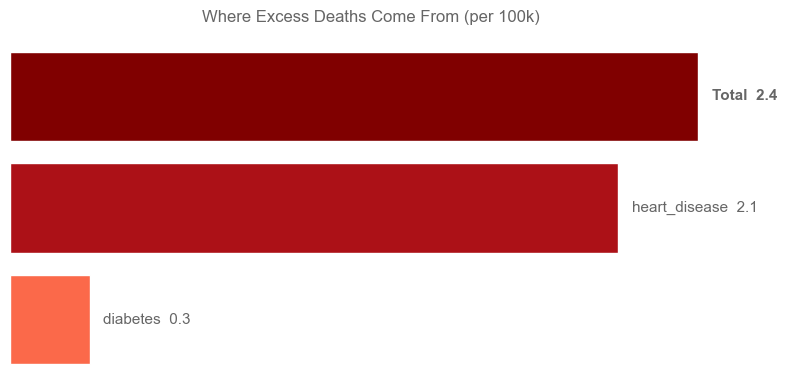

In [183]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# DATA (exclude obesity)
# -----------------------------
excess_filtered = {
    k: v for k, v in excess.items()
    if k.lower() not in ["obesity", "heart_attack"]
}

# Compute total
total_value = sum(excess_filtered.values())

# Add total
excess_with_total = dict(excess_filtered)
excess_with_total["Total"] = total_value

# Sort (keep Total last manually)
items = sorted(
    [(k, v) for k, v in excess_with_total.items() if k != "Total"],
    key=lambda x: x[1]
)
items.append(("Total", total_value))

labels, values = zip(*items)

# -----------------------------
# COLORS (Reds palette)
# -----------------------------
colors = list(plt.cm.Reds(np.linspace(0.5, 0.85, len(values)-1)))
colors.append((0.5, 0, 0))  # darker red for Total

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(labels, values, color=colors)

# -----------------------------
# LABELS ON BARS
# -----------------------------
for i, (label, value) in enumerate(zip(labels, values)):
    ax.text(
        value + max(values)*0.02,
        i,
        f"{label}  {value:.1f}",
        va='center',
        fontsize=11,
        color='#666666',
        fontweight='bold' if label == "Total" else 'normal'
    )

# -----------------------------
# STYLE
# -----------------------------
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Where Excess Deaths Come From (per 100k)",
    fontsize=12,
    color='#666666',
    pad=10
)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

plt.tight_layout()
plt.show()

In [184]:
US_POP = 330_000_000

# Example: food insecurity rate (you computed this)
fi_rate = 0.12   # replace with yours

fi_pop = US_POP * fi_rate
fs_pop = US_POP * (1 - fi_rate)

In [186]:
# Example values (replace with your real ones)
rates = {
    "diabetes": {
        "secure": 0.14,
        "insecure": 0.23
    },
    "heart_disease": {
        "secure": 0.06,
        "insecure": 0.11
    }
}

# Convert to counts
flows = {}

for disease, vals in rates.items():
    flows[disease] = {
        "secure": fs_pop * vals["secure"],
        "insecure": fi_pop * vals["insecure"]
    }

In [187]:
mortality = {
    "diabetes": 28.8 / 100000,
    "heart_disease": 218.3 / 100000  # use your avg
}

death_flows = {}

for disease in flows:
    death_flows[disease] = {
        "secure": flows[disease]["secure"] * mortality[disease],
        "insecure": flows[disease]["insecure"] * mortality[disease]
    }

In [188]:
import plotly.graph_objects as go

# -----------------------------
# NODES
# -----------------------------
labels = [
    "Food Secure", "Food Insecure",
    "Diabetes", "Heart Disease", "Heart Attack",
    "Deaths"
]

# Index map
idx = {label: i for i, label in enumerate(labels)}

# -----------------------------
# LINKS
# -----------------------------
source = []
target = []
value = []

# 1️⃣ Food → Disease
for disease in flows:
    source.append(idx["Food Secure"])
    target.append(idx[disease.replace("_", " ").title()])
    value.append(flows[disease]["secure"])

    source.append(idx["Food Insecure"])
    target.append(idx[disease.replace("_", " ").title()])
    value.append(flows[disease]["insecure"])

# 2️⃣ Disease → Death
for disease in death_flows:
    source.append(idx[disease.replace("_", " ").title()])
    target.append(idx["Deaths"])
    value.append(
        death_flows[disease]["secure"] +
        death_flows[disease]["insecure"]
    )

# -----------------------------
# PLOT
# -----------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=20,
        color="rgba(200,200,200,0.8)"
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="rgba(200,0,0,0.4)"
    )
)])

fig.update_layout(
    title="Food Insecurity → Disease → Deaths (U.S. Population)",
    font=dict(color="#666666")
)

fig.show()

In [189]:
import plotly.graph_objects as go

# -----------------------------
# 1. BASE POPULATION
# -----------------------------
US_POP = 330_000_000

# Replace with YOUR actual rate
fi_rate = 0.12

fi_pop = US_POP * fi_rate
fs_pop = US_POP * (1 - fi_rate)

# -----------------------------
# 2. DISEASE PREVALENCE (replace with yours)
# -----------------------------
rates = {
    "Diabetes": {"secure": 0.14, "insecure": 0.23},
    "Heart Disease": {"secure": 0.06, "insecure": 0.11},
}

# -----------------------------
# 3. MORTALITY (per person, NOT per 100k)
# -----------------------------
mortality = {
    "Diabetes": 28.8 / 100000,
    "Heart Disease": 213.8 / 100000
}

# -----------------------------
# 4. BUILD FLOWS
# -----------------------------
source = []
target = []
value = []

labels = [
    "Food Secure", "Food Insecure",
    "Diabetes", "Heart Disease", "Heart Attack",
    "Deaths"
]

idx = {label: i for i, label in enumerate(labels)}

# Track total deaths
total_deaths = 0

for disease in rates:
    # People with disease
    secure_cases = fs_pop * rates[disease]["secure"]
    insecure_cases = fi_pop * rates[disease]["insecure"]

    # Scale down flows (important for Sankey readability)
    scale = 1e6  # keeps numbers manageable visually

    # -----------------------------
    # Food → Disease
    # -----------------------------
    source += [idx["Food Secure"], idx["Food Insecure"]]
    target += [idx[disease], idx[disease]]
    value  += [secure_cases/scale, insecure_cases/scale]

    # -----------------------------
    # Disease → Death
    # -----------------------------
    deaths = (secure_cases + insecure_cases) * mortality[disease]
    total_deaths += deaths

    source.append(idx[disease])
    target.append(idx["Deaths"])
    value.append(deaths/scale)

# -----------------------------
# 5. PLOT
# -----------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=20,
        color="rgba(180,180,180,0.8)"
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="rgba(200,0,0,0.35)"
    )
)])

fig.update_layout(
    title=f"Food Insecurity → Disease → Deaths (Total ≈ {int(total_deaths):,} deaths/year)",
    font=dict(color="#666666"),
    paper_bgcolor="rgba(0,0,0,0)"
)

fig.show()